# Analiza filtru Kalmana - predykcja trajektorii 2D

Notebook prezentuje wyniki symulacji filtru Kalmana (model stałej prędkości, CV 2D).
Każda sekcja bada inny aspekt działania FK i jego wpływ na jakość estymacji i predykcji.

## Spis treści

1. Pojedynczy przebieg.
2. Analiza wpływu szumu pomiarowego sigma.
3. Analiza wpływu horyzontu predykcji.
4. Filtr Kalmana vs naiwny predyktor.
5. Strojenie parametru Q.
6. Estymacja prędkości (vx, vy) z samych pomiarów pozycji.
7. Szum dropout i outlierów.
8. Weryfikacja na danych rzeczywistych (TrajAir) i realna predykcja położenia do przodu.
9. Wnioski końcowe.


In [104]:
%matplotlib inline

import sys
from pathlib import Path

project_root = Path(".").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.simulation import run_simulation
from src.metrics import rmse, mae, sigma_analysis, horizon_analysis
from src.viz import plot_results, plot_sigma_analysis, plot_horizon_analysis

In [105]:
import os, re
import matplotlib.pyplot as _mplt
from matplotlib._pylab_helpers import Gcf

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

_fig_counter = [0]
_in_autoshow = [False]

# Zawsze przechwyć PRAWDZIWY oryginalny show (nawet przy wielokrotnym uruchomieniu komórki)
if not hasattr(_mplt, "_orig_show_backup"):
    _mplt._orig_show_backup = _mplt.show
_orig_show = _mplt._orig_show_backup

def _autoshow():
    if _in_autoshow[0]:
        return                  # blokuj rekursję - nic nie rób
    _in_autoshow[0] = True
    try:
        for manager in list(Gcf.get_all_fig_managers()):
            fig = manager.canvas.figure
            _fig_counter[0] += 1
            sup  = fig._suptitle.get_text() if fig._suptitle else ""
            slug = re.sub(r"[^\w\s-]", "", sup[:50]).strip().replace(" ", "_")
            fname = (f"fig_{_fig_counter[0]:02d}_{slug}.png" if slug
                     else f"fig_{_fig_counter[0]:02d}.png")
            fig.savefig(os.path.join(RESULTS_DIR, fname), dpi=150, bbox_inches="tight")
        _orig_show()            # _in_autoshow jest True podczas _orig_show - blokuje rekursję
    finally:
        _in_autoshow[0] = False

_mplt.show = _autoshow          # nadpisz przez moduł, nie przez alias
plt.show   = _autoshow
print(f"Auto-save wykresów do folderu results/")

Auto-save wykresów do folderu results/


---
## 1. Pojedynczy przebieg.

Parametry bazowe: N=60 kroków, σ=2.0, q_gen=0.05 (prawdziwa dynamika), q_filter=0.01 (model filtru),
horyzont predykcji h=10, seed=42.

Różnica q_gen != q_filter to **realistyczny model mismatch** - w praktyce nie znamy dokładnie
jak bardzo obiekt manewruje, więc q_filter dobieramy konserwatywnie lub heurystycznie.

In [106]:
cfg = {
    "N":        60,
    "dt":       1.0,
    "sigma":    2.0,
    "q_gen":    0.05,   
    "q_filter": 0.01,   
    "horizon":  10,
    "seed":     42,
}

print("Parametry symulacji:")
for k, v in cfg.items():
    print(f"  {k}: {v}")

Parametry symulacji:
  N: 60
  dt: 1.0
  sigma: 2.0
  q_gen: 0.05
  q_filter: 0.01
  horizon: 10
  seed: 42


In [107]:
res = run_simulation(
    N=cfg["N"],
    dt=cfg["dt"],
    sigma=cfg["sigma"],
    q=cfg["q_gen"],
    horizon=cfg["horizon"],
    seed=cfg["seed"],
    q_filter=cfg["q_filter"],
)

# Wyciągnij główne tablice do dalszej analizy
states      = res["states"]
meas        = res["measurements"]
estimates   = res["estimates"]
predictions = res["predictions"]
N_sim       = len(states)
horizon     = cfg["horizon"]

print(f"RMSE estymacji : {res['rmse_est']:.4f}")
print(f"MAE  estymacji : {res['mae_est']:.4f}")
print(f"RMSE predykcji : {res['rmse_pred']:.4f}")
print(f"MAE  predykcji : {res['mae_pred']:.4f}")

RMSE estymacji : 1.8750
MAE  estymacji : 1.6784
RMSE predykcji : 10.6504
MAE  predykcji : 8.1400


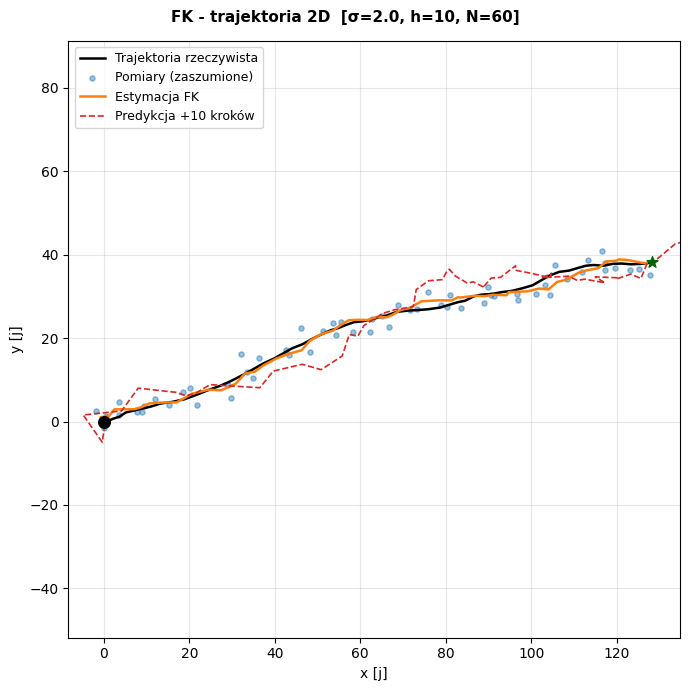

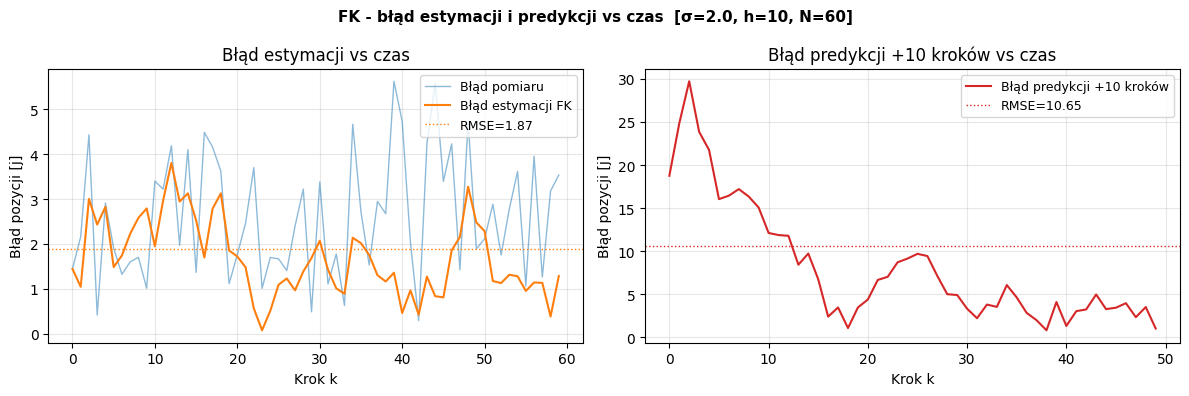

In [ ]:
# Wykres 1: trajektoria 2D (kwadratowy) ───
fig1, ax = plt.subplots(figsize=(7, 7))
fig1.suptitle(
    f"FK - trajektoria 2D  [σ={cfg['sigma']}, h={cfg['horizon']}, N={cfg['N']}]",
    fontsize=11, fontweight="bold",
)

ax.plot(states[:, 0], states[:, 1], "k-", lw=1.8, label="Trajektoria rzeczywista")
ax.scatter(meas[:, 0], meas[:, 1], s=14, c="tab:blue", alpha=0.45, label="Pomiary (zaszumione)")
ax.plot(estimates[:, 0], estimates[:, 1], color="tab:orange", lw=1.8, label="Estymacja FK")
ax.plot(predictions[:, 0], predictions[:, 1], color="tab:red", lw=1.2,
        linestyle="--", label=f"Predykcja +{horizon} kroków")
ax.scatter(*states[0, :2],  s=70, c="k",        zorder=5)
ax.scatter(*states[-1, :2], s=70, c="darkgreen", zorder=5, marker="*")

all_x = np.concatenate([states[:, 0], meas[:, 0], estimates[:, 0]])
all_y = np.concatenate([states[:, 1], meas[:, 1], estimates[:, 1]])
cx = (all_x.min() + all_x.max()) / 2
cy = (all_y.min() + all_y.max()) / 2
half = max(all_x.max() - all_x.min(), all_y.max() - all_y.min()) / 2 * 1.1
ax.set_xlim(cx - half, cx + half)
ax.set_ylim(cy - half, cy + half)
ax.set_xlabel("x [j]"); ax.set_ylabel("y [j]")
ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wykres 2: błąd estymacji i predykcji vs czas ──────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle(
    f"FK - błąd estymacji i predykcji vs czas  [σ={cfg['sigma']}, h={cfg['horizon']}, N={cfg['N']}]",
    fontsize=11, fontweight="bold",
)

err_est  = np.linalg.norm(estimates[:, :2] - states[:, :2], axis=1)
err_meas = np.linalg.norm(meas - states[:, :2], axis=1)

ax1 = axes[0]
ax1.plot(err_meas, color="tab:blue",   alpha=0.5, lw=1,   label="Błąd pomiaru")
ax1.plot(err_est,  color="tab:orange", lw=1.5,           label="Błąd estymacji FK")
ax1.axhline(res["rmse_est"], color="tab:orange", lw=1, ls=":",
            label=f"RMSE={res['rmse_est']:.2f}")
ax1.set_xlabel("Krok k"); ax1.set_ylabel("Błąd pozycji [j]")
ax1.set_title("Błąd estymacji vs czas"); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
pred_err = np.linalg.norm(predictions[:N_sim - horizon] - states[horizon:, :2], axis=1)
ax2.plot(pred_err, color="tab:red", lw=1.5, label=f"Błąd predykcji +{horizon} kroków")
ax2.axhline(res["rmse_pred"], color="tab:red", lw=1, ls=":",
            label=f"RMSE={res['rmse_pred']:.2f}")
ax2.set_xlabel("Krok k"); ax2.set_ylabel("Błąd pozycji [j]")
ax2.set_title(f"Błąd predykcji +{horizon} kroków vs czas"); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Pierwszy wykres - trajektoria 2D - pokazuje trzy serie danych na tle tej samej rzeczywistej trasy:
pomiary (niebieskie punkty) rozrzucone wokół czarnej linii to wpływ szumu σ=2.0,
estymacja FK (pomarańczowa) biegnie między nimi a prawdziwą trasą - filtr "wygładza" szum.
Przerywana czerwona linia to predykcja o h=10 kroków do przodu wychodząca z aktualnej estymacji.

Powyżej (błąd vs czas) ilościowo potwierdza to samo: niebieski błąd pomiaru oscyluje wokół σ,
pomarańczowy błąd estymacji FK leży wyraźnie niżej - to efekt filtrowania.
Czerwony błąd predykcji jest najwyższy, bo ekstrapolacja na 10 kroków kumuluje niepewność prędkości. 

---
## 2. Analiza wpływu szumu pomiarowego sigma.

Badamy jak RMSE i MAE zmieniają się dla σ ∈ {0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0}.
Większy szum → sensor dostarcza mniej wiarygodnych pomiarów → filtr musi bardziej polegać na modelu.

In [109]:
sigmas = [0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]

df_sigma = sigma_analysis(
    sigmas,
    N=cfg["N"], dt=cfg["dt"], q=cfg["q_gen"],
    horizon=cfg["horizon"], seed=cfg["seed"],
    q_filter=cfg["q_filter"],
)

display(df_sigma.style.format(precision=4))

,sigma,rmse_est,mae_est,rmse_pred,mae_pred
0,0.3000,0.3973,0.3546,7.4961,6.1026
1,0.5000,0.6157,0.5464,8.0692,6.4159
2,1.0000,1.0916,0.9722,9.1917,7.0811
3,1.5000,1.5055,1.3495,10.0086,7.6493
4,2.0000,1.8750,1.6784,10.6504,8.1400
5,3.0000,2.5271,2.2468,11.6734,8.9772
6,4.0000,3.1152,2.7426,12.5478,9.6849
7,5.0000,3.6735,3.2316,13.3674,10.3365
8,6.0000,4.2184,3.7117,14.1618,10.9549
9,8.0000,5.2951,4.6394,15.7050,12.2049


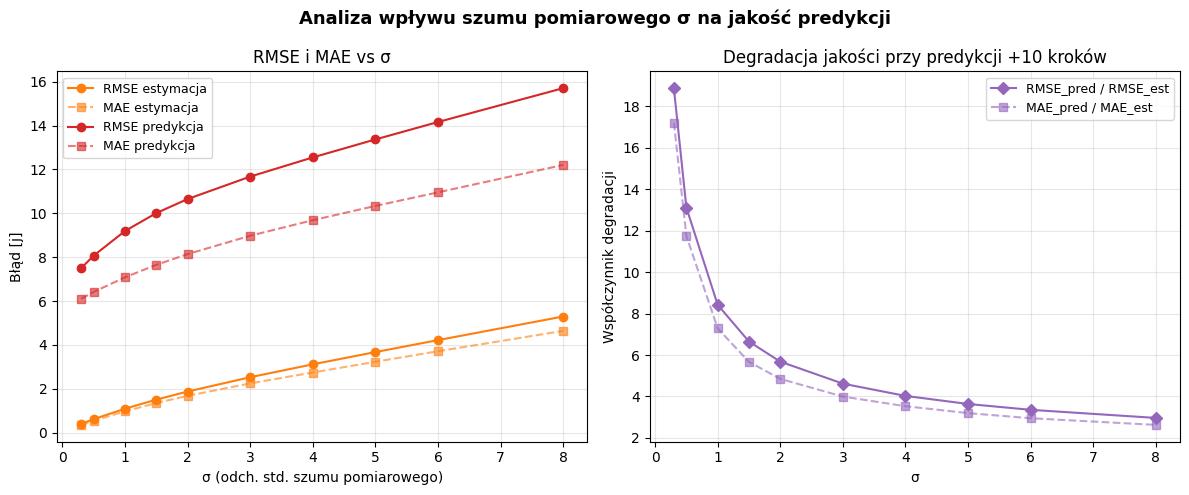

In [110]:
plot_sigma_analysis(
    sigmas,
    dt=cfg["dt"], q=cfg["q_gen"], horizon=cfg["horizon"],
    N=cfg["N"], seed=cfg["seed"],
    q_filter=cfg["q_filter"],
    show=True,
)

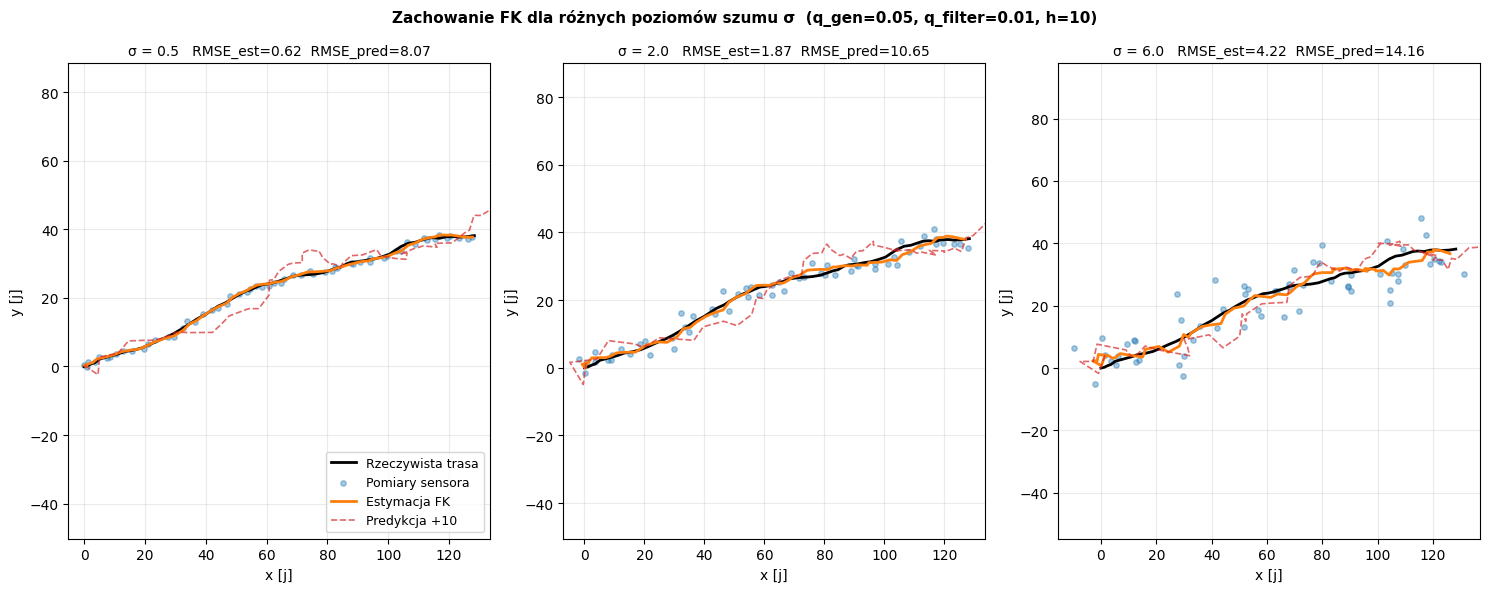

In [111]:
# Wizualizacja: jak FK zachowuje się dla trzech poziomów σ
showcase_sigmas = [0.5, 2.0, 6.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle(
    f"Zachowanie FK dla różnych poziomów szumu σ  (q_gen={cfg['q_gen']}, q_filter={cfg['q_filter']}, h={cfg['horizon']})",
    fontsize=11, fontweight="bold",
)

for ax, s in zip(axes, showcase_sigmas):
    r = run_simulation(cfg["N"], cfg["dt"], s, cfg["q_gen"], cfg["horizon"],
                       seed=cfg["seed"], q_filter=cfg["q_filter"])
    st_   = r["states"]; ms_ = r["measurements"]
    est_  = r["estimates"]; pred_ = r["predictions"]

    ax.plot(st_[:, 0],   st_[:, 1],  "k-",         lw=2,   label="Rzeczywista trasa")
    ax.scatter(ms_[:, 0], ms_[:, 1], s=15, c="tab:blue", alpha=0.4, label="Pomiary sensora")
    ax.plot(est_[:, 0],  est_[:, 1], color="tab:orange", lw=2,   label="Estymacja FK")
    ax.plot(pred_[:, 0], pred_[:, 1], "--", color="tab:red", lw=1.2, alpha=0.7,
            label=f"Predykcja +{cfg['horizon']}")

    all_x = np.concatenate([st_[:, 0], ms_[:, 0], est_[:, 0]])
    all_y = np.concatenate([st_[:, 1], ms_[:, 1], est_[:, 1]])
    cx = (all_x.min() + all_x.max()) / 2
    cy = (all_y.min() + all_y.max()) / 2
    half = max(all_x.max() - all_x.min(), all_y.max() - all_y.min()) / 2 * 1.08
    ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)

    ax.set_title(f"σ = {s}   RMSE_est={r['rmse_est']:.2f}  RMSE_pred={r['rmse_pred']:.2f}", fontsize=10)
    ax.set_xlabel("x [j]"); ax.set_ylabel("y [j]")
    ax.grid(True, alpha=0.25)
    if s == showcase_sigmas[0]:
        ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()


Wraz ze wzrostem σ sensor dostarcza coraz mniej wiarygodnych pomiarów. FK zwiększa wagę własnej predykcji modelu kosztem obserwacji (wzmocnienie K maleje). Widoczne jest to jako większe rozjechanie niebieskich punktów od czarnej trasy. RMSE estymacji rośnie proporcjonalnie do σ, ale wolniej niż sam szum - FK uśrednia historię. RMSE predykcji (h=10) rośnie szybciej: bardziej zaszumiona estymacja prędkości przekłada się na błędniejszą ekstrapolację, a czerwona przerywana linia wyraźnie oddala się od prawdziwej trasy przy wysokich σ. Poniżej wizualizacja zachowania filtru dla trzech poziomów σ.

### Wzmocnienie Kalmana K a dokładność pomiaru

Wzmocnienie Kalmana K opisuje, jak bardzo filtr ufa pomiarowi względem modelu ruchu.
Zależy bezpośrednio od stosunku R/Q - czyli szumu pomiarowego do szumu procesowego.

- **Duże σ → duże R → małe K**: filtr woli model, słabo reaguje na pomiary.
- **Małe σ → małe R → duże K ≈ 1**: filtr prawie całkowicie ufa pomiarom.

K maleje z czasem do wartości stacjonarnej - wyznaczonej po kilkunastu krokach nie zmienia się już istotnie.

sigma=0.5  (bardzo maly szum)        K_stacj=0.4871
sigma=2.0  (domyslny)                K_stacj=0.2744
sigma=5.0  (duzy szum)               K_stacj=0.1822
sigma=8.0  (bardzo duzy szum)        K_stacj=0.1468


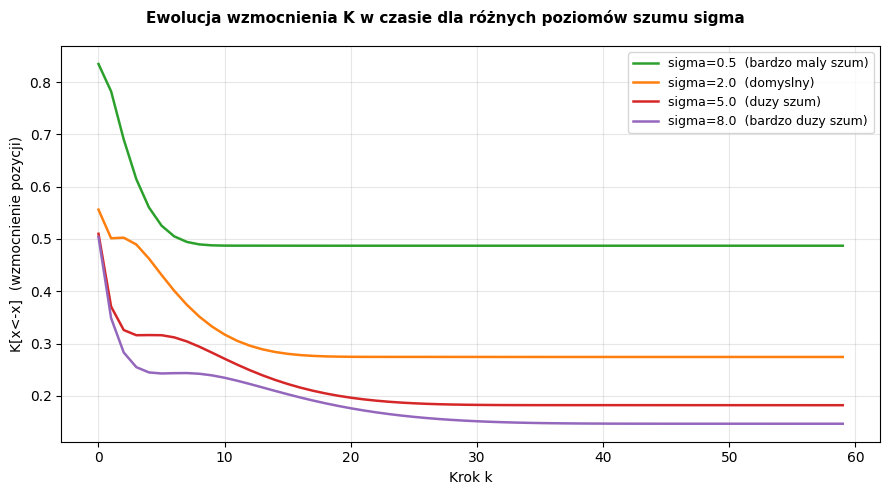

In [112]:
from src.model import build_F, build_H, build_Q, build_R
from src.kalman import KalmanFilter as _KF

# Wzmocnienie K[x<-x] dla roznych sigma
SIGMA_CASES = [
    (0.5,  'tab:green',  'sigma=0.5  (bardzo maly szum)'),
    (2.0,  'tab:orange', 'sigma=2.0  (domyslny)'),
    (5.0,  'tab:red',    'sigma=5.0  (duzy szum)'),
    (8.0,  'tab:purple', 'sigma=8.0  (bardzo duzy szum)'),
]

_F_k = build_F(cfg['dt']); _H_k = build_H(); _Qk = build_Q(cfg['q_filter'])
_x0k = np.array([meas[0,0], meas[0,1], 0., 0.])

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    'Ewolucja wzmocnienia K w czasie dla różnych poziomów szumu sigma',
    fontsize=11, fontweight='bold',
)

for sigma_, col_, lbl_ in SIGMA_CASES:
    _R_k = build_R(sigma_)
    _P0k = np.diag([sigma_**2, sigma_**2, 1., 1.])
    kf_  = _KF(_F_k, _H_k, _Qk, _R_k, _x0k.copy(), _P0k.copy())
    kxx  = []
    for k_ in range(cfg['N']):
        kf_.predict()
        S_  = kf_.H @ kf_.P @ kf_.H.T + kf_.R
        K_  = kf_.P @ kf_.H.T @ np.linalg.inv(S_)
        kxx.append(K_[0, 0])
        kf_.update(meas[k_])
    ax.plot(kxx, color=col_, lw=1.8, label=lbl_)
    print(f'{lbl_:35s}  K_stacj={kxx[-1]:.4f}')

ax.set_xlabel('Krok k'); ax.set_ylabel('K[x<-x]  (wzmocnienie pozycji)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Wykres pokazuje kluczową właściwość wzmocnienia Kalmana: **K konwerguje do wartości stacjonarnej
po kilku–kilkunastu krokach** niezależnie od stanu początkowego.

Przy **małym σ** (zielony): R małe → K utrzymuje się powyżej lub na poziomie 0,5 → filtr bardziej ufa pomiarom,
koryguje stan w każdym kroku o pełną innowację.

Przy **dużym σ** (fioletowy): R duże → K małe → filtr woli model ruchu,
słabo reaguje na pomiary. Estymacja jest gładka, ale wolno nadąża za zmianami.

Wartość stacjonarna K wyznacza „punkt równowagi" filtrowania:
im większy szum pomiaru, tym bardziej FK zachowuje się jak ekstrapolacja modelowa.

---
## 3. Analiza wpływu horyzontu predykcji.

Sprawdzamy jak błąd predykcji rośnie wraz z horyzontem n ∈ {1, 5, 10, 20}.
Im dalej w przód przewidujemy, tym większa niepewność - obiekt może zmienić kierunek,
a model zakłada stałą prędkość.

In [113]:
horizons = [1, 5, 10, 20]

df_h = horizon_analysis(
    horizons,
    N=cfg["N"], dt=cfg["dt"], sigma=cfg["sigma"],
    q=cfg["q_gen"], seed=cfg["seed"],
    q_filter=cfg["q_filter"],
)

display(df_h.style.format(precision=4))

,horizon,rmse_est,mae_est,rmse_pred,mae_pred
0,1,1.8750,1.6784,2.4361,2.1572
1,5,1.8750,1.6784,5.5249,4.6031
2,10,1.8750,1.6784,10.6504,8.1400
3,20,1.8750,1.6784,21.9549,16.2606


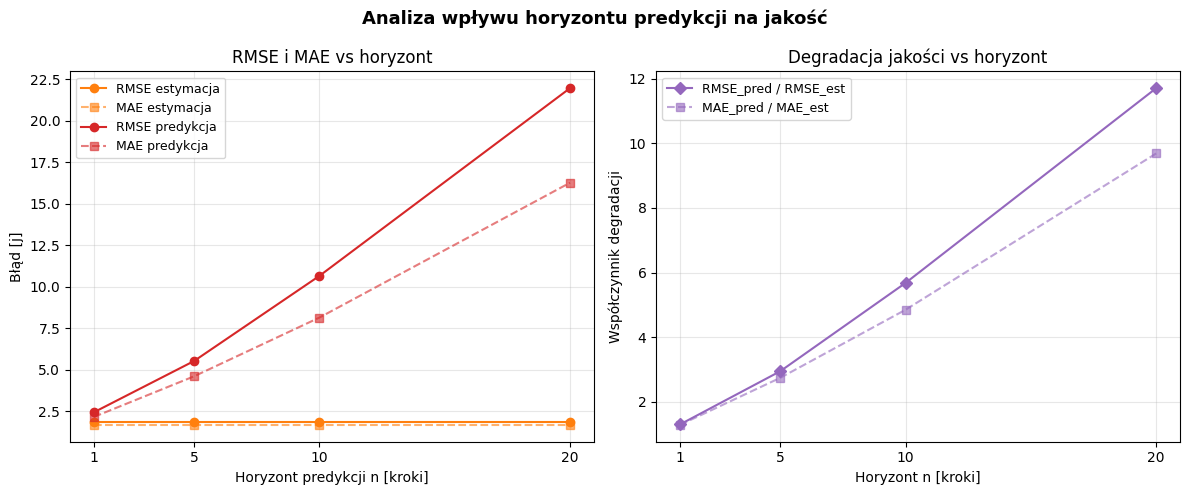

In [114]:
plot_horizon_analysis(df_h, show=True)

Błąd predykcji RMSE rośnie z horyzontem - każdy dodatkowy krok mnoży niepewność prędkości przez Δt. RMSE **estymacji** pozostaje praktycznie stałe niezależnie od horyzontu (to tylko kwestia optymalizacji bieżącej pozycji, nie przyszłości). Gradient RMSE predykcji zależy od szybkości zmian kierunku obiektu - dla CV model jest dokładny na krótkich horyzontach. Poniżej wizualizacja, jak daleko "sięga" strzałka predykcji dla różnych horyzontów.

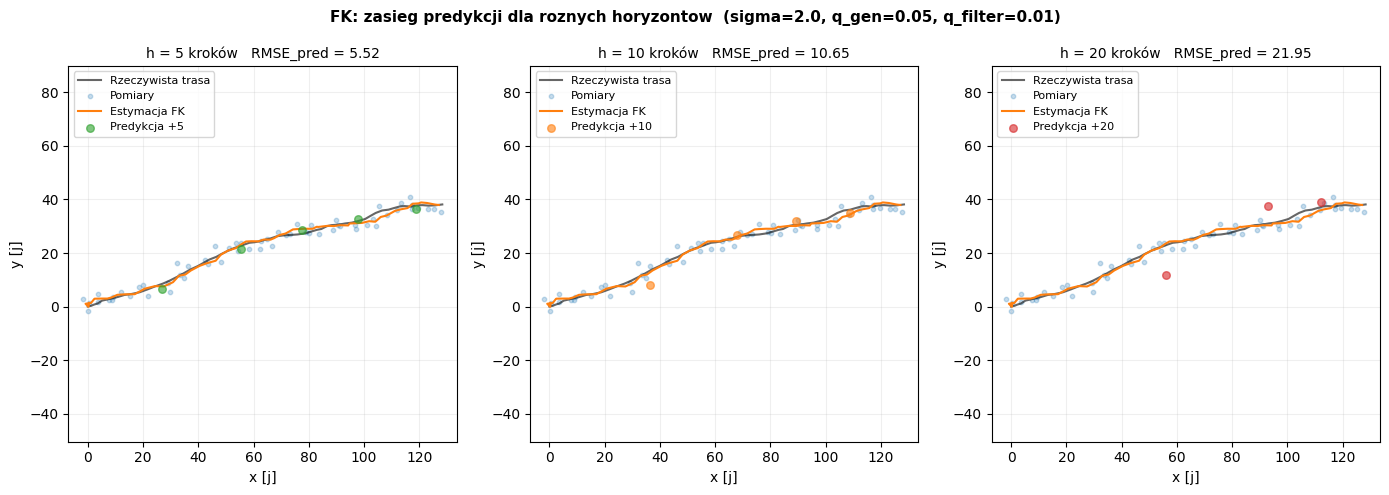

In [115]:
# Wizualizacja: predykcja FK dla h=5, 10, 20
showcase_horizons = [5, 10, 20]
colors_h = ['tab:green', 'tab:orange', 'tab:red']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    f"FK: zasieg predykcji dla roznych horyzontow  (sigma={cfg['sigma']}, "
    f"q_gen={cfg['q_gen']}, q_filter={cfg['q_filter']})",
    fontsize=11, fontweight='bold',
)

for idx, (h, col) in enumerate(zip(showcase_horizons, colors_h)):
    ax = axes[idx]
    r = run_simulation(cfg['N'], cfg['dt'], cfg['sigma'], cfg['q_gen'], h,
                       seed=cfg['seed'], q_filter=cfg['q_filter'])
    st_  = r['states']; est_ = r['estimates']; ms_ = r['measurements']

    ax.plot(st_[:, 0],  st_[:, 1],  'k-',  lw=1.5, alpha=0.6, label='Rzeczywista trasa')
    ax.scatter(ms_[:, 0], ms_[:, 1], s=10, c='tab:blue', alpha=0.25, label='Pomiary')
    ax.plot(est_[:, 0], est_[:, 1], color='tab:orange', lw=1.5, label='Estymacja FK')

    snap_steps = range(10, cfg['N'] - h, 10)
    ax.scatter(
        [r['predictions'][s_][0] for s_ in snap_steps],
        [r['predictions'][s_][1] for s_ in snap_steps],
        s=30, marker='o', color=col, alpha=0.6, zorder=4, label=f'Predykcja +{h}',
    )

    all_x = np.concatenate([st_[:, 0], ms_[:, 0], est_[:, 0]])
    all_y = np.concatenate([st_[:, 1], ms_[:, 1], est_[:, 1]])
    cx = (all_x.min() + all_x.max()) / 2; cy = (all_y.min() + all_y.max()) / 2
    half = max(all_x.max() - all_x.min(), all_y.max() - all_y.min()) / 2 * 1.08
    ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)

    sfx = 'kroków'
    ax.set_title(f'h = {h} {sfx}   RMSE_pred = {r["rmse_pred"]:.2f}', fontsize=10)
    ax.set_xlabel('x [j]'); ax.set_ylabel('y [j]')
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

Widzimy że im dalszy horyzont do predykcji tym pomiary są mmiej dokładne i oddalają się od rzeczywistej trasy.

---
## 4. Filtr Kalmana vs naiwny predyktor.

### Co to jest naiwny predyktor?

**Naiwny predyktor** to najprostsza możliwa metoda przewidywania przyszłej pozycji obiektu:

> *"Za n kroków obiekt będzie dokładnie tam, gdzie jest teraz."*

Matematycznie: `pred_naiwna(k) = measurement(k)` - ostatni znany pomiar jest traktowany jako prognoza na wszystkie przyszłe chwile.

**Dlaczego to "naiwne"?** Metoda zakłada, że obiekt stoi w miejscu. Ignoruje:
- prędkość,
- historię trajektorii,
- jakikolwiek model dynamiki.

Naiwny predyktor jest powszechnie stosowany jako **punkt odniesienia (baseline)** w analizach algorytmów predykcji - jeśli nasz algorytm nie pokonuje nawet tej metody, to coś jest nie tak.

### Jak filtr Kalmana radzi sobie lepiej?

FK estymuje pełny wektor stanu `[x, y, vx, vy]`. Dzięki prędkości obliczonej z historii pomiarów może **ekstrapolować pozycję do przodu** po linii ruchu. Dla horyzontu n kroków FK przewiduje:

```
pred_FK(k) ≈ est_pos(k) + est_vel(k) * n * dt
```

Im szybszy i bardziej liniowy ruch obiektu, tym FK wygrywa więcej. Im bardziej statyczny obiekt, tym naiwny predyktor jest porównywalny.

In [116]:
# Naiwna predykcja: przewiduj ostatni znany pomiar jako pozycję za horizon kroków
naive_pred  = meas[:N_sim - horizon]     # predykcja na kroku k = meas[k]
true_future = states[horizon:, :2]        # prawdziwa pozycja za horizon kroków

rmse_naive = rmse(naive_pred, true_future)
mae_naive  = mae(naive_pred,  true_future)
rmse_fk    = res["rmse_pred"]
mae_fk     = res["mae_pred"]

poprawa_rmse = 100 * (rmse_naive - rmse_fk) / rmse_naive
poprawa_mae  = 100 * (mae_naive  - mae_fk)  / mae_naive

df_compare = pd.DataFrame({
    "Metoda":           ["Filtr Kalmana", "Naiwny predyktor"],
    "RMSE":             [rmse_fk,  rmse_naive],
    "MAE":              [mae_fk,   mae_naive],
    "Poprawa RMSE [%]": [poprawa_rmse, 0.0],
    "Poprawa MAE [%]":  [poprawa_mae,  0.0],
})

display(df_compare.style.format({
    "RMSE": "{:.4f}", "MAE": "{:.4f}",
    "Poprawa RMSE [%]": "{:.1f}", "Poprawa MAE [%]": "{:.1f}",
}))

print(f"\nFK redukuje RMSE predykcji o {poprawa_rmse:.1f}% i MAE o {poprawa_mae:.1f}% względem metody naiwnej.")

,Metoda,RMSE,MAE,Poprawa RMSE [%],Poprawa MAE [%]
0,Filtr Kalmana,10.6504,8.1400,55.9,66.0
1,Naiwny predyktor,24.1320,23.9107,0.0,0.0



FK redukuje RMSE predykcji o 55.9% i MAE o 66.0% względem metody naiwnej.


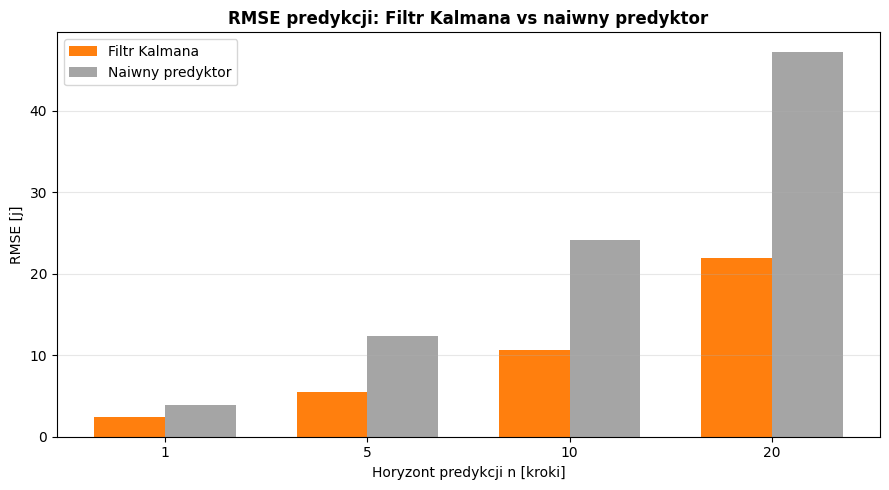

In [117]:
# Wykres słupkowy: FK vs naiwny dla różnych horyzontów
labels = [str(h) for h in horizons]
rmse_fk_list    = df_h["rmse_pred"].tolist()
rmse_naive_list = []

for h in horizons:
    np_pred = meas[:N_sim - h]
    tf      = states[h:, :2]
    rmse_naive_list.append(rmse(np_pred, tf))

x = np.arange(len(horizons))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_fk    = ax.bar(x - width/2, rmse_fk_list,    width, label="Filtr Kalmana",     color="tab:orange")
bars_naive = ax.bar(x + width/2, rmse_naive_list, width, label="Naiwny predyktor",  color="tab:gray",   alpha=0.7)

ax.set_xlabel("Horyzont predykcji n [kroki]")
ax.set_ylabel("RMSE [j]")
ax.set_title("RMSE predykcji: Filtr Kalmana vs naiwny predyktor", fontsize=12, fontweight="bold")
ax.set_xticks(x, labels)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

FK wygrywa z naiwnym predyktorem tym bardziej, im dłuższy horyzont - przy h=1 różnica jest niewielka (obiekt nie zdążył się ruszyć daleko), przy h=20 FK ma kilkakrotnie mniejszy błąd. Metoda naiwna nie skaluje się z horyzontem, bo nie modeluje prędkości. Wynik potwierdza, że **informacja o prędkości zawarta w historii pomiarów jest kluczowym atutem FK**.

---
## 5. Strojenie parametru Q. 

Parametr Q (macierz szumu procesowego) opisuje **jak bardzo ufamy modelowi dynamiki**:

- **Q zbyt małe** (Q → 0): filtr jest sztywny - bardzo ufa modelowi CV, ignoruje zmiany kursu. Estymacja jest gładka, ale wolno nadąża za manewrami. Wygrywa przy powolnych obiektach.
- **Q zbyt duże** (Q → ∞): filtr jest reaktywny - prawie całkowicie ufa pomiarom, mało filtruje. Estymacja podąża za szumem. Wygrywa przy bardzo dynamicznych obiektach.
- **Q dopasowane** do rzeczywistości: optymalny kompromis.

W praktyce Q jest parametrem kalibracyjnym - dobiera się go przez obserwację zachowania filtru na danych testowych. Domyślny scenariusz tej analizy to q_gen=0.05, q_filter=0.01 - filtr jest konserwatywny (niedostrojony). Poniżej sprawdzamy pełne spektrum q_filter przy stałym q_gen=0.05.

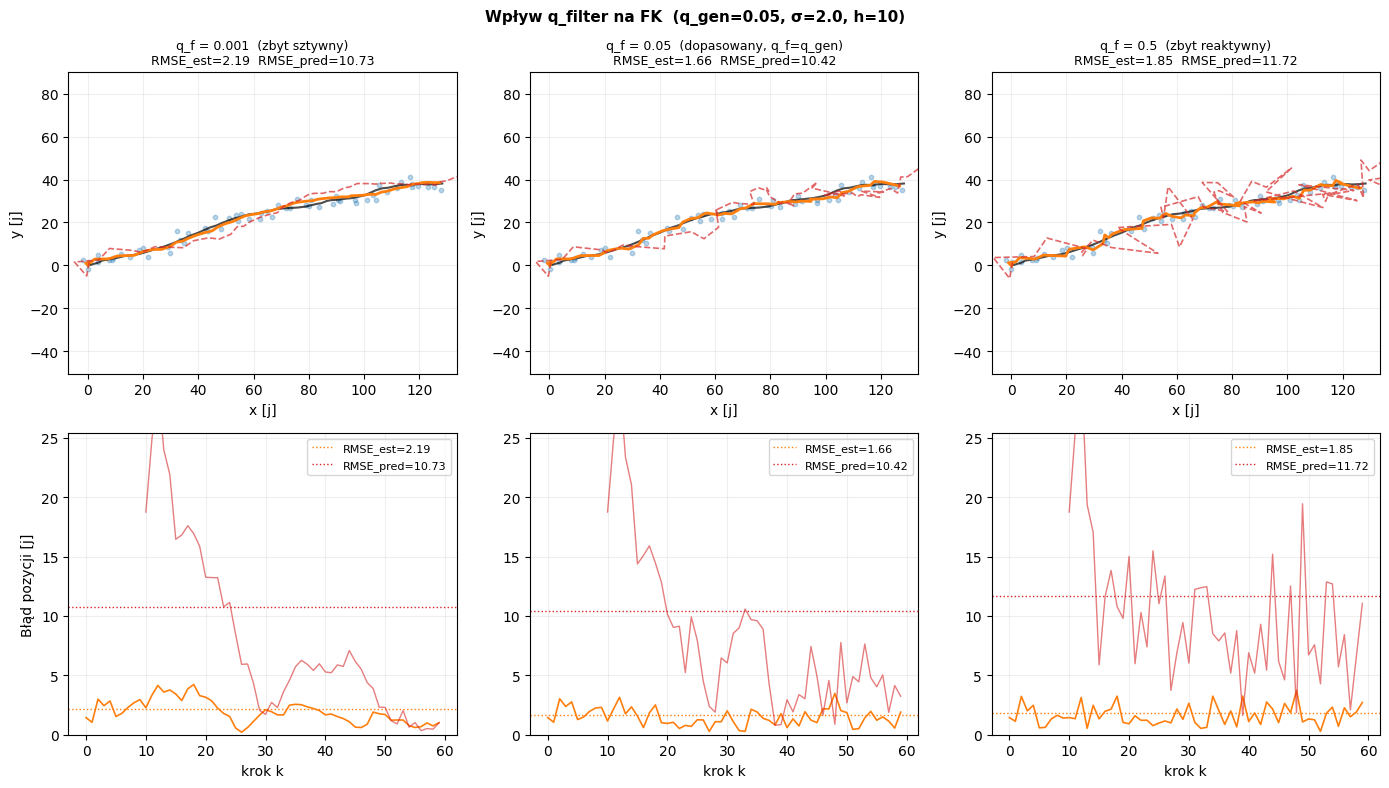

,q_filter,RMSE_est,RMSE_pred,Opis
0,0.0010,2.1949,10.7272,zbyt sztywny
1,0.0100,1.8750,10.6504,lekko niedostrojony (domyślny)
2,0.0500,1.6599,10.4219,optymalny (dopasowany)
3,0.2000,1.7089,10.7067,nadstrojony
4,0.5000,1.8458,11.7181,zbyt reaktywny


In [ ]:
# Wizualizacja: FK dla 3 kluczowych q_filter (q_gen stałe = 0.05) ──────────
Q_GEN         = cfg["q_gen"]
Q_FILTERS_ALL = [0.001, 0.01, 0.05, 0.2, 0.5]
OPIS_ALL      = ["zbyt sztywny", "lekko niedostrojony (domyślny)",
                 "optymalny (dopasowany)", "nadstrojony", "zbyt reaktywny"]

runs_all = []
rmse_est_q, rmse_pred_q = [], []
for q_f in Q_FILTERS_ALL:
    r = run_simulation(cfg["N"], cfg["dt"], cfg["sigma"], Q_GEN, cfg["horizon"],
                       seed=cfg["seed"], q_filter=q_f)
    runs_all.append(r)
    rmse_est_q.append(r["rmse_est"])
    rmse_pred_q.append(r["rmse_pred"])

SHOW_IDX    = [0, 2, 4]
LABELS_SHOW = [
    "0.001  (zbyt sztywny)",
    "0.05  (dopasowany, q_f=q_gen)",
    "0.5  (zbyt reaktywny)",
]

errs_show = [
    np.linalg.norm(runs_all[i]["estimates"][:, :2] - runs_all[i]["states"][:, :2], axis=1)
    for i in SHOW_IDX
]
err_ymax = max(e.max() for e in errs_show) * 6

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(
    f"Wpływ q_filter na FK  (q_gen={Q_GEN}, σ={cfg['sigma']}, h={cfg['horizon']})",
    fontsize=11, fontweight="bold",
)

for col_i, (idx, lbl, err_t) in enumerate(zip(SHOW_IDX, LABELS_SHOW, errs_show)):
    r    = runs_all[idx]
    st_  = r["states"]; ms_ = r["measurements"]
    est_ = r["estimates"]; pred_ = r["predictions"]

    ax_top = axes[0, col_i]
    ax_top.plot(st_[:, 0],   st_[:, 1],  "k-",          lw=1.5, alpha=0.7)
    ax_top.scatter(ms_[:, 0], ms_[:, 1], s=10, c="tab:blue", alpha=0.3)
    ax_top.plot(est_[:, 0],  est_[:, 1], color="tab:orange", lw=2.0)
    ax_top.plot(pred_[:, 0], pred_[:, 1], "--", color="tab:red", lw=1.2, alpha=0.7)

    all_x = np.concatenate([st_[:, 0], ms_[:, 0], est_[:, 0]])
    all_y = np.concatenate([st_[:, 1], ms_[:, 1], est_[:, 1]])
    cx = (all_x.min() + all_x.max()) / 2; cy = (all_y.min() + all_y.max()) / 2
    half = max(all_x.max() - all_x.min(), all_y.max() - all_y.min()) / 2 * 1.08
    ax_top.set_xlim(cx - half, cx + half); ax_top.set_ylim(cy - half, cy + half)
    ax_top.set_title(
        f"q_f = {lbl}\nRMSE_est={r['rmse_est']:.2f}  RMSE_pred={r['rmse_pred']:.2f}",
        fontsize=9,
    )
    ax_top.set_xlabel("x [j]"); ax_top.set_ylabel("y [j]"); ax_top.grid(True, alpha=0.2)

    ax_bot = axes[1, col_i]
    ax_bot.plot(err_t, color="tab:orange", lw=1.2)
    ax_bot.axhline(r["rmse_est"], color="tab:orange", ls=":", lw=1,
                   label=f"RMSE_est={r['rmse_est']:.2f}")
    pred_err_q = np.linalg.norm(
        r["predictions"][:cfg["N"]-cfg["horizon"]] - r["states"][cfg["horizon"]:, :2], axis=1)
    ax_bot.plot(range(cfg["horizon"], cfg["N"]), pred_err_q,
                color="tab:red", lw=1.0, alpha=0.6)
    ax_bot.axhline(r["rmse_pred"], color="tab:red", ls=":", lw=1,
                   label=f"RMSE_pred={r['rmse_pred']:.2f}")
    ax_bot.set_xlabel("krok k"); ax_bot.set_ylim(0, err_ymax)
    ax_bot.legend(fontsize=8, loc="upper right"); ax_bot.grid(True, alpha=0.2)
    if col_i == 0:
        ax_bot.set_ylabel("Błąd pozycji [j]")

plt.tight_layout()
plt.show()

# Tabela
df_q = pd.DataFrame({
    "q_filter":  Q_FILTERS_ALL,
    "RMSE_est":  [round(v, 4) for v in rmse_est_q],
    "RMSE_pred": [round(v, 4) for v in rmse_pred_q],
    "Opis":      OPIS_ALL,
})
display(df_q.style.format(precision=4))


Przy Q zbyt małym estymowana trasa jest nadmiernie wygładzona - filtr nie reaguje na zakręty (wolna konwergencja K). Widoczne spóźnianie się linii pomarańczowej za czarną. **Predykcja (przerywana czerwona)** jest wtedy jeszcze bardziej wygładzona - FK ekstrapoluje z opóźnioną prędkością i mija zakręty na dalszym horyzoncie (h=10). Przy Q zbyt dużym estymacja podąża za szumem, a predykcja staje się chaotyczna. Minimum RMSE_est i RMSE_pred leży przy Q ≈ Q_gen, co potwierdza optymalność FK przy dopasowanych parametrach.

---
### Parametr Q dla estymacji i predykcji

Estymacja i predykcja mają odmienne wymagania względem parametru q:
- Estymacja: optymalny kompromis między szumem a modelem → minimum przy q_filter ≈ q_gen.
- Predykcja: zależy od stabilności prędkości w wektorze stanu; filtr zbyt reaktywny
  szacuje prędkość niestabilnie → błąd ekstrapolacji rośnie.

Poniżej sweep q_filter na skali logarytmicznej - jak q_filter wpływa na RMSE_est i RMSE_pred.

Optymalne q_filter dla RMSE_est  : 0.0702  (RMSE_est=1.6509)
Optymalne q_filter dla RMSE_pred : 0.0702  (RMSE_pred=10.4099)
q_gen (prawdziwa dynamika)        : 0.05


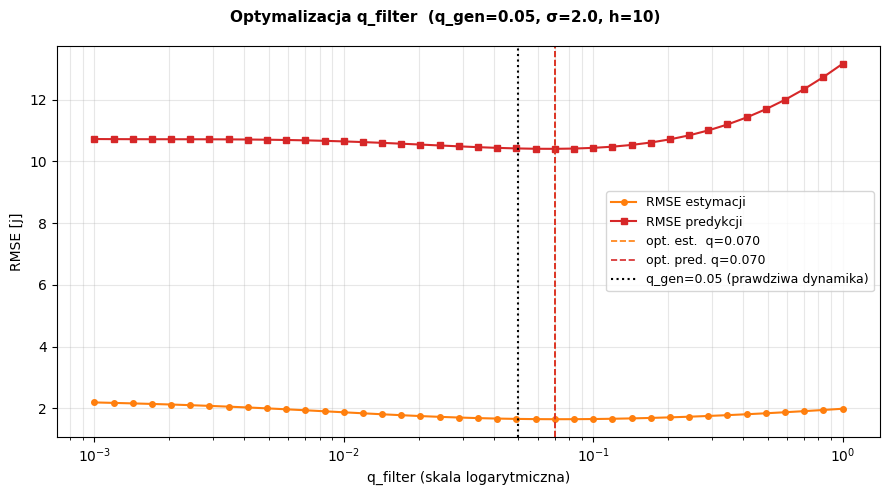

In [ ]:
from src.model import build_F, build_H, build_Q, build_R
from src.kalman import KalmanFilter as _KF

# Sweep q_filter: RMSE_est i RMSE_pred na skali log ────────────────────────
q_sweep = np.logspace(-3, 0, 40)   # 0.001 … 1.0

rmse_est_sw, rmse_pred_sw = [], []
for q_f in q_sweep:
    r = run_simulation(cfg["N"], cfg["dt"], cfg["sigma"], cfg["q_gen"],
                       cfg["horizon"], seed=cfg["seed"], q_filter=q_f)
    rmse_est_sw.append(r["rmse_est"])
    rmse_pred_sw.append(r["rmse_pred"])

idx_est_opt  = int(np.argmin(rmse_est_sw))
idx_pred_opt = int(np.argmin(rmse_pred_sw))

print(f"Optymalne q_filter dla RMSE_est  : {q_sweep[idx_est_opt]:.4f}  "
      f"(RMSE_est={rmse_est_sw[idx_est_opt]:.4f})")
print(f"Optymalne q_filter dla RMSE_pred : {q_sweep[idx_pred_opt]:.4f}  "
      f"(RMSE_pred={rmse_pred_sw[idx_pred_opt]:.4f})")
print(f"q_gen (prawdziwa dynamika)        : {cfg['q_gen']}")

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    f"Optymalizacja q_filter  (q_gen={cfg['q_gen']}, \u03c3={cfg['sigma']}, h={cfg['horizon']})",
    fontsize=11, fontweight="bold",
)
ax.semilogx(q_sweep, rmse_est_sw,  "o-", ms=4, color="tab:orange", label="RMSE estymacji")
ax.semilogx(q_sweep, rmse_pred_sw, "s-", ms=4, color="tab:red",    label="RMSE predykcji")
ax.axvline(q_sweep[idx_est_opt],  color="tab:orange", ls="--", lw=1.2,
           label=f"opt. est.  q={q_sweep[idx_est_opt]:.3f}")
ax.axvline(q_sweep[idx_pred_opt], color="tab:red",    ls="--", lw=1.2,
           label=f"opt. pred. q={q_sweep[idx_pred_opt]:.3f}")
ax.axvline(cfg["q_gen"], color="k", ls=":", lw=1.5,
           label=f"q_gen={cfg['q_gen']} (prawdziwa dynamika)")
ax.set_xlabel("q_filter (skala logarytmiczna)")
ax.set_ylabel("RMSE [j]")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

Na wykresie oba optima zbiegają się przy q≈0.07 (blisko q_gen=0.05) - przy krótkich trajektoriach
i umiarkowanym horyzoncie różnica bywa niezauważalna.

Ważniejszy wniosek to **asymetria RMSE_pred**: krzywa jest płaska dla małych q i stroma dla dużych q.
Zbyt małe q_filter - filtr jest konserwatywny, RMSE_est rośnie umiarkowanie, RMSE_pred prawie się nie zmienia.
Zbyt duże q_filter - filtr śledzi szum, destabilizuje prędkość, RMSE_pred gwałtownie rośnie.

**Praktyczny wniosek:** przy strojeniu pod predykcję bezpieczniej jest wybrać q zbyt małe niż zbyt duże -
zbyt reaktywny filtr szacuje prędkość niestabilnie i błąd predykcji rośnie szybciej niż błąd estymacji.

---
## 6. Estymacja prędkości (vx, vy) z samych pomiarów pozycji.

Filtr Kalmana estymuje pełny wektor stanu `[x, y, vx, vy]`, mimo że sensor mierzy
wyłącznie pozycję `[x, y]`. Prędkość jest wywnioskowana z sekwencji pomiarów.
Poniżej porównanie estymowanej prędkości z prawdziwą.

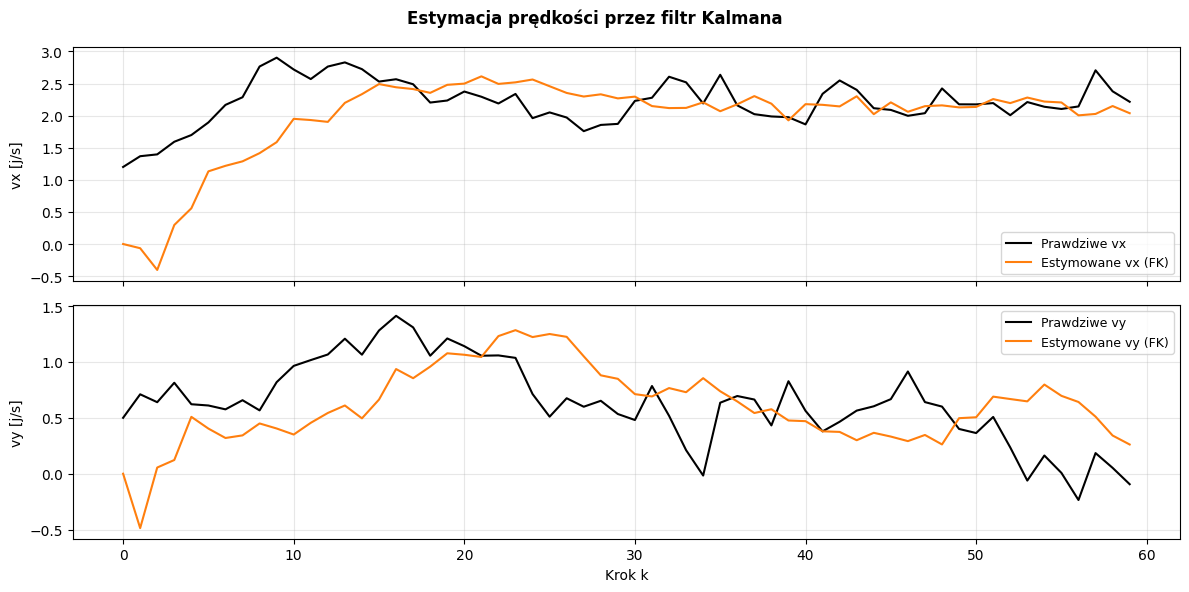

RMSE estymacji vx: 0.6006 j/s
RMSE estymacji vy: 0.4442 j/s


In [120]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle("Estymacja prędkości przez filtr Kalmana", fontsize=12, fontweight="bold")

for ax, comp, label in zip(axes, [2, 3], ["vx", "vy"]):
    ax.plot(states[:, comp],    "k-",          lw=1.5, label=f"Prawdziwe {label}")
    ax.plot(estimates[:, comp], color="tab:orange", lw=1.5, label=f"Estymowane {label} (FK)")
    ax.set_ylabel(f"{label} [j/s]")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Krok k")
plt.tight_layout()
plt.show()

rmse_vx = float(np.sqrt(np.mean((estimates[:, 2] - states[:, 2])**2)))
rmse_vy = float(np.sqrt(np.mean((estimates[:, 3] - states[:, 3])**2)))
print(f"RMSE estymacji vx: {rmse_vx:.4f} j/s")
print(f"RMSE estymacji vy: {rmse_vy:.4f} j/s")

FK wyznacza prędkość wyłącznie z sekwencji pomiarów pozycji - bez żadnego dedykowanego czujnika.
Na początku trajektorii estymacja prędkości jest opóźniona (filtr potrzebuje kilku kroków historii),
ale szybko konwerguje do prawdziwych wartości `vx`, `vy`. RMSE prędkości jest wyższe niż RMSE pozycji,
bo prędkość jest wielkością pochodną - błąd pozycji jest amplifikowany przez numeryczne różniczkowanie
wbudowane w model stanu.

---
## 7. Szum dropout i outlierów.

### Kontekst rzeczywisty

W warunkach operacyjnych sensor nigdy nie jest idealny. Dwa ważne typy zakłóceń:

**Dropout (zaniknięcie sygnału):** sensor co pewien czas nie dostarcza żadnego pomiaru.
- GPS: tunele, wąwozy miejskie, przeszkody terenowe
- Radar: martwe strefy, zakłócenia wielościeżkowe
- ADS-B: poza zasięgiem nadajnika, chwilowa utrata łączności

**Outlier (skok pomiaru):** sensor dostarcza pomiar z dużo większym błędem niż normalnie.
- Multipath GPS: odbicia sygnału od budynków - błąd kilkaset metrów
- Radary: fałszywe echa, zakłócenia EMI
- Czujniki optyczne: oślepienie przez słońce, refleksje

### Jak radzi sobie FK?

- **Dropout:** FK naturalnie kontynuuje predykcję bez aktualizacji - niepewność P rośnie,
  ale zysk Kalmana kompensuje to przy powrocie sensora. FK jest **naturalnie odporny**.

- **Outlier:** Klasyczny FK nie ma mechanizmu detekcji - traktuje każdy pomiar jako wiarygodny.
  Skoki 8×σ potrafią mocno przesunąć estymację. To fundamentalne ograniczenie. Aby temu zaradzić 
  zostało dodane bramkowanie innowacji (innovation gating), które ma na celu odrzucać takie outliery.

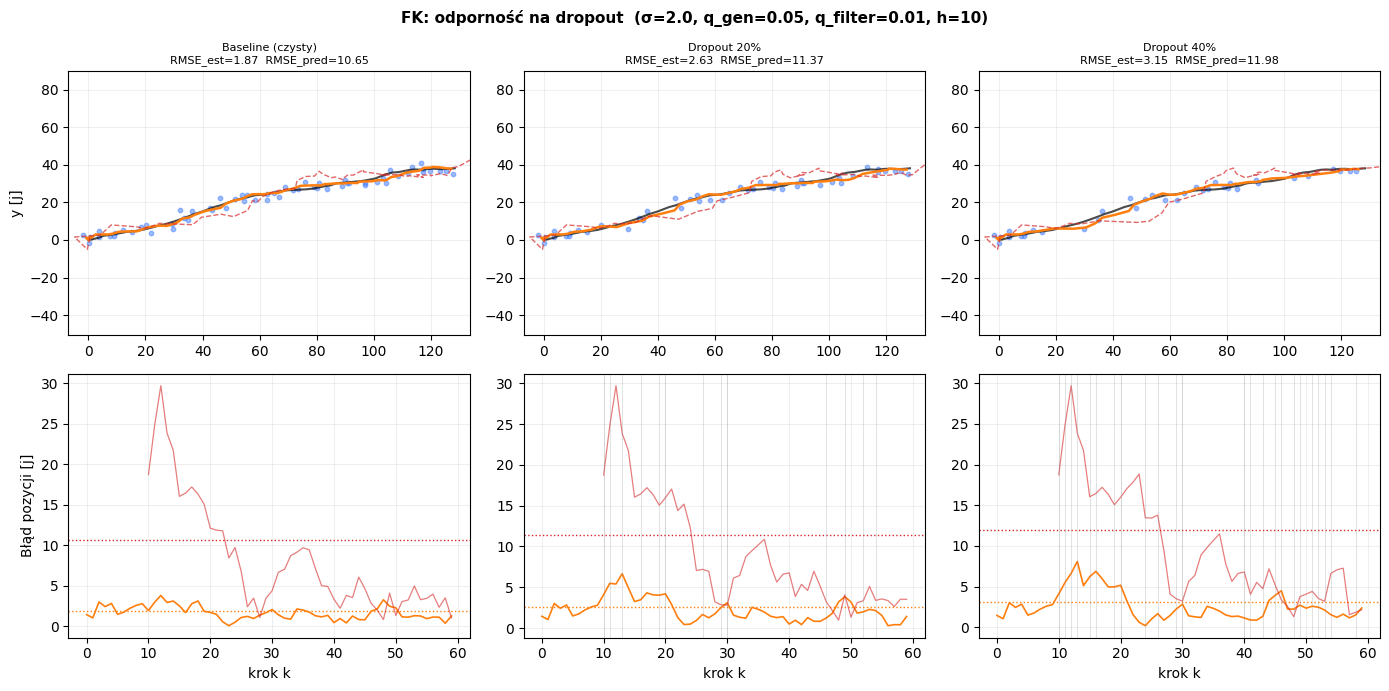

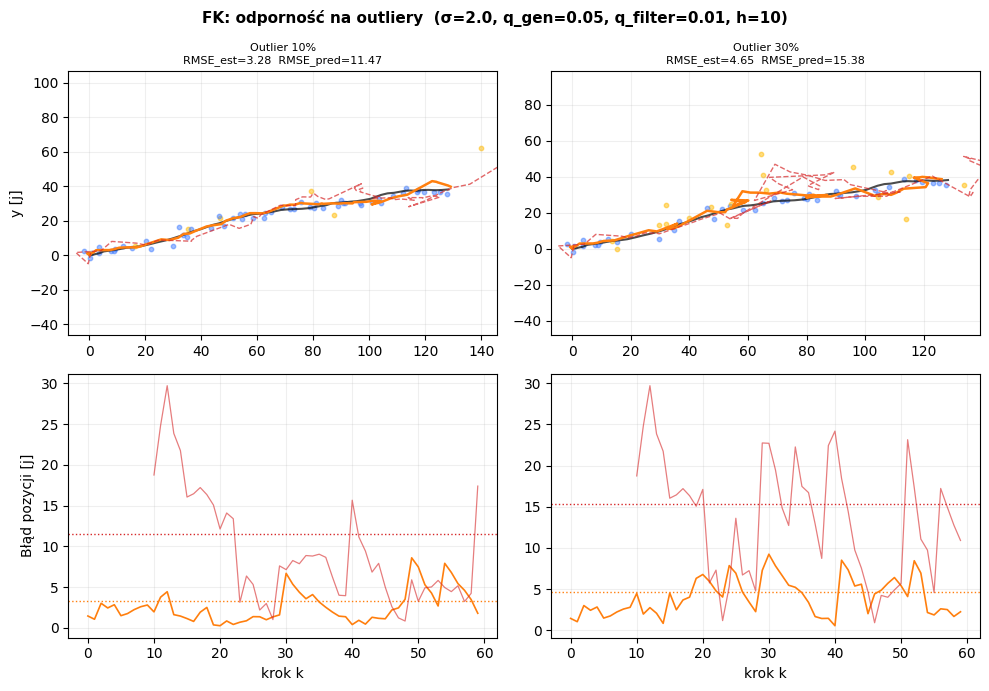

In [ ]:
# Baseline (brak szumów) vs dropout vs outlierów ───────────────────────────
SCENARIOS = [
    ("Baseline (czysty)",  dict(p_dropout=0.0,  p_outlier=0.0)),
    ("Dropout 20%",        dict(p_dropout=0.20, p_outlier=0.0)),
    ("Dropout 40%",        dict(p_dropout=0.40, p_outlier=0.0)),
    ("Outlier 10%",        dict(p_dropout=0.0,  p_outlier=0.10)),
    ("Outlier 30%",        dict(p_dropout=0.0,  p_outlier=0.30)),
]

results_noise = {}
for label, kw in SCENARIOS:
    results_noise[label] = run_simulation(
        cfg["N"], cfg["dt"], cfg["sigma"], cfg["q_gen"],
        cfg["horizon"], seed=cfg["seed"], q_filter=cfg["q_filter"], **kw)

def _draw_group(group_labels, ncols, figsize, suptitle):
    fig, axes = plt.subplots(2, ncols, figsize=figsize, squeeze=False)
    fig.suptitle(suptitle, fontsize=11, fontweight="bold")
    for col, label in enumerate(group_labels):
        r   = results_noise[label]
        st_ = r["states"]; ms_ = r["measurements"]
        est_ = r["estimates"]; pred_ = r["predictions"]
        vm  = r["valid"];  om  = r["outlier_mask"]

        ax_t = axes[0, col]
        ax_t.plot(st_[:, 0], st_[:, 1], "k-", lw=1.5, alpha=0.7)
        for i in range(len(st_)):
            if vm[i]:
                c = (1.0, 0.73, 0.0) if om[i] else (0.25, 0.49, 1.0)
                ax_t.scatter(ms_[i, 0], ms_[i, 1], s=10, c=[c], alpha=0.5)
        ax_t.plot(est_[:, 0], est_[:, 1], color="tab:orange", lw=1.8)
        ax_t.plot(pred_[:, 0], pred_[:, 1], "--", color="tab:red", lw=1.0, alpha=0.7)
        ax_t.set_title(f"{label}\nRMSE_est={r['rmse_est']:.2f}  RMSE_pred={r['rmse_pred']:.2f}", fontsize=8)
        all_x = np.concatenate([st_[:, 0], ms_[:, 0], est_[:, 0]])
        all_y = np.concatenate([st_[:, 1], ms_[:, 1], est_[:, 1]])
        cx = (all_x.min() + all_x.max()) / 2; cy = (all_y.min() + all_y.max()) / 2
        half = max(all_x.max() - all_x.min(), all_y.max() - all_y.min()) / 2 * 1.08
        ax_t.set_xlim(cx - half, cx + half); ax_t.set_ylim(cy - half, cy + half)
        ax_t.grid(True, alpha=0.2)

        ax_e = axes[1, col]
        err_t = np.linalg.norm(est_[:, :2] - st_[:, :2], axis=1)
        ax_e.plot(err_t, color="tab:orange", lw=1.2)
        ax_e.axhline(r["rmse_est"], color="tab:orange", ls=":", lw=1.0)
        pred_err_ = np.linalg.norm(
            pred_[:cfg["N"]-cfg["horizon"]] - st_[cfg["horizon"]:, :2], axis=1)
        ax_e.plot(range(cfg["horizon"], cfg["N"]), pred_err_,
                  color="tab:red", lw=0.9, alpha=0.6)
        ax_e.axhline(r["rmse_pred"], color="tab:red", ls=":", lw=1.0)
        for d in np.where(~vm)[0]:
            ax_e.axvline(d, color="gray", lw=0.4, alpha=0.4)
        ax_e.set_xlabel("krok k"); ax_e.grid(True, alpha=0.2)
        if col == 0:
            ax_e.set_ylabel("Błąd pozycji [j]")

    axes[0, 0].set_ylabel("y [j]")
    plt.tight_layout()
    plt.show()

_draw_group(
    ["Baseline (czysty)", "Dropout 20%", "Dropout 40%"],
    ncols=3, figsize=(14, 7),
    suptitle=f"FK: odporność na dropout  (σ={cfg['sigma']}, q_gen={cfg['q_gen']}, q_filter={cfg['q_filter']}, h={cfg['horizon']})",
)
_draw_group(
    ["Outlier 10%", "Outlier 30%"],
    ncols=2, figsize=(10, 7),
    suptitle=f"FK: odporność na outliery  (σ={cfg['sigma']}, q_gen={cfg['q_gen']}, q_filter={cfg['q_filter']}, h={cfg['horizon']})",
)


── Wpływ DROPOUT ──


,dropout %,RMSE_est,MAE_est,RMSE_pred
0,0%,1.8750,1.6784,10.6504
1,5%,2.0873,1.8299,10.7632
2,10%,2.1782,1.9017,10.8679
3,20%,2.6289,2.2193,11.3662
4,30%,2.9081,2.3829,11.6039
5,40%,3.1501,2.6234,11.9819



── Wpływ OUTLIERÓW ──


,outlier %,RMSE_est,MAE_est,RMSE_pred
0,0%,1.8750,1.6784,10.6504
1,5%,2.0796,1.7979,11.0692
2,10%,3.2812,2.6170,11.4700
3,20%,3.5583,3.0414,12.6534
4,30%,4.6452,4.0717,15.3778


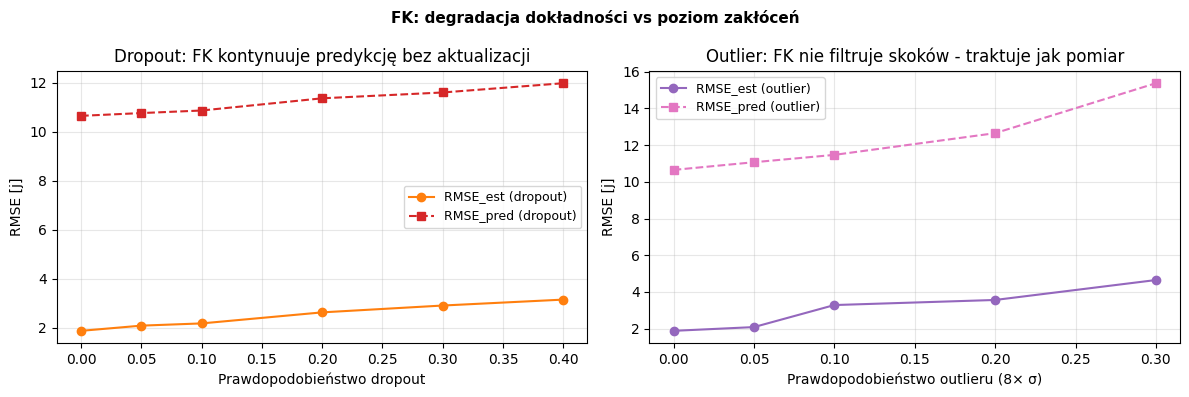

In [ ]:
# Tabela: RMSE vs poziom dropout i outlierów ────────────────────────────────
drop_rates    = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40]
outlier_rates = [0.0, 0.05, 0.10, 0.20, 0.30]

rows_d, rows_o = [], []
for p in drop_rates:
    r = run_simulation(cfg["N"], cfg["dt"], cfg["sigma"], cfg["q_gen"],
                       cfg["horizon"], seed=cfg["seed"],
                       q_filter=cfg["q_filter"], p_dropout=p)
    rows_d.append({"dropout %": f"{int(p*100)}%", "RMSE_est": round(r["rmse_est"], 4),
                   "MAE_est": round(r["mae_est"], 4), "RMSE_pred": round(r["rmse_pred"], 4)})

for p in outlier_rates:
    r = run_simulation(cfg["N"], cfg["dt"], cfg["sigma"], cfg["q_gen"],
                       cfg["horizon"], seed=cfg["seed"],
                       q_filter=cfg["q_filter"], p_outlier=p)
    rows_o.append({"outlier %": f"{int(p*100)}%", "RMSE_est": round(r["rmse_est"], 4),
                   "MAE_est": round(r["mae_est"], 4), "RMSE_pred": round(r["rmse_pred"], 4)})

df_drop    = pd.DataFrame(rows_d)
df_outlier = pd.DataFrame(rows_o)

print("Wpływ DROPOUT ──")
display(df_drop.style.format(precision=4))
print("\nWpływ OUTLIERÓW ──")
display(df_outlier.style.format(precision=4))

# Wykres: RMSE vs p_dropout i p_outlier ───
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("FK: degradacja dokładności vs poziom zakłóceń", fontsize=11, fontweight="bold")

ax = axes[0]
ax.plot(drop_rates, df_drop["RMSE_est"],  "o-", color="tab:orange", label="RMSE_est (dropout)")
ax.plot(drop_rates, df_drop["RMSE_pred"], "s--", color="tab:red",   label="RMSE_pred (dropout)")
ax.set_xlabel("Prawdopodobieństwo dropout"); ax.set_ylabel("RMSE [j]")
ax.set_title("Dropout: FK kontynuuje predykcję bez aktualizacji"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(outlier_rates, df_outlier["RMSE_est"],  "o-", color="tab:purple", label="RMSE_est (outlier)")
ax2.plot(outlier_rates, df_outlier["RMSE_pred"], "s--", color="tab:pink",  label="RMSE_pred (outlier)")
ax2.set_xlabel("Prawdopodobieństwo outlieru (8× σ)"); ax2.set_ylabel("RMSE [j]")
ax2.set_title("Outlier: FK nie filtruje skoków - traktuje jak pomiar"); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- **Dropout:** RMSE estymacji rośnie umiarkowanie nawet przy 40% dropout - FK utrzymuje poprawną trajektorię przez predykcję modelu. Pionowe szare linie w dolnym wierszu oznaczają kroki bez pomiaru. **Predykcja (czerwona przerywana, h=10)** jest silniej zaburzona przy dropoucie: bez pomiaru filtr nie koryguje prędkości, więc ekstrapolacja za 10 kroków gromadzi więcej błędu. FK jest **naturalnie odporny** na brakujące obserwacje w zakresie estymacji; predykcja jest bardziej czuła.

- **Outlierów:** Wzrost RMSE jest gwałtowniejszy już przy 10-20% outlierów. Żółte punkty to pomiary 8×σ - FK wierzy im i skacze. Predykcja amplifikuje ten skok: błędna estymacja prędkości po outlierze przekłada się na niepoprawną trajektorię predykcji h=10 kroków do przodu. Rozwiązanie: **bramkowanie** (*innovation gating*) eliminuje outliery przed wejściem do filtra.

Baseline (brak outlierów)     : RMSE_est = 1.8750
Outlier 30% - bez bramkowania : RMSE_est = 4.6452
Outlier 30% - z bramkowaniem  : RMSE_est = 3.6005


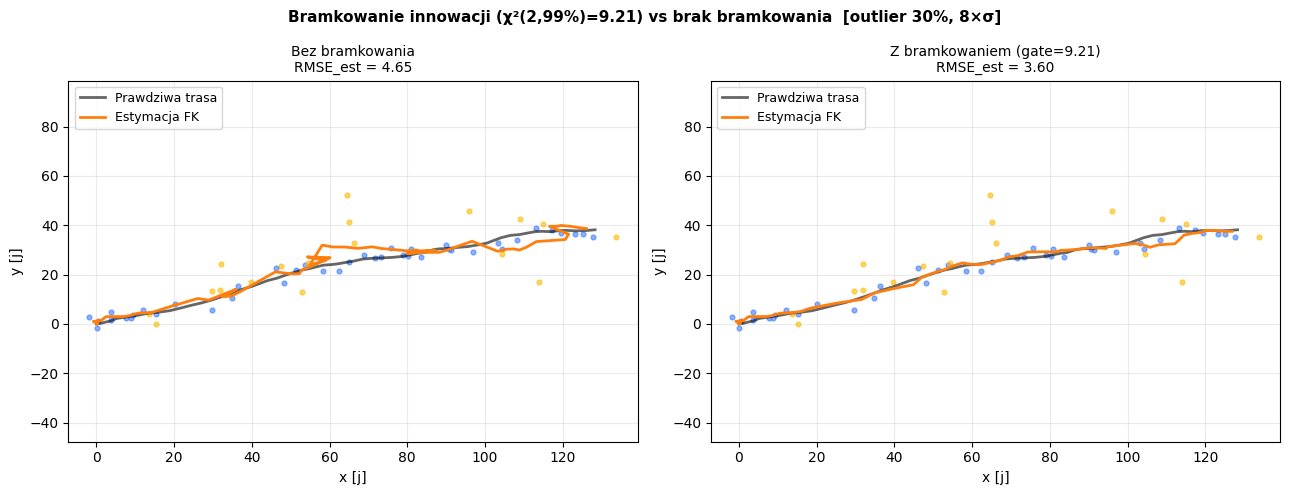

In [ ]:
# Bramkowanie innowacji: FK bez gatingu vs z gatingiem ─────────────────────
GATE_THRESHOLD = 9.21   # chi²(2, 99%)

p_outlier_demo = 0.30

r_no_gate = run_simulation(cfg["N"], cfg["dt"], cfg["sigma"], cfg["q_gen"],
                           cfg["horizon"], seed=cfg["seed"],
                           q_filter=cfg["q_filter"], p_outlier=p_outlier_demo)

r_gated = run_simulation(cfg["N"], cfg["dt"], cfg["sigma"], cfg["q_gen"],
                         cfg["horizon"], seed=cfg["seed"],
                         q_filter=cfg["q_filter"], p_outlier=p_outlier_demo,
                         gate_threshold=GATE_THRESHOLD)

print(f"Baseline (brak outlierów)     : RMSE_est = {results_noise['Baseline (czysty)']['rmse_est']:.4f}")
print(f"Outlier {int(p_outlier_demo*100)}% - bez bramkowania : RMSE_est = {r_no_gate['rmse_est']:.4f}")
print(f"Outlier {int(p_outlier_demo*100)}% - z bramkowaniem  : RMSE_est = {r_gated['rmse_est']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f"Bramkowanie innowacji (χ²(2,99%)={GATE_THRESHOLD}) vs brak bramkowania  "
    f"[outlier {int(p_outlier_demo*100)}%, 8×σ]",
    fontsize=11, fontweight="bold",
)

for ax, (r_, title_) in zip(axes, [
    (r_no_gate, f"Bez bramkowania\nRMSE_est = {r_no_gate['rmse_est']:.2f}"),
    (r_gated,   f"Z bramkowaniem (gate={GATE_THRESHOLD})\nRMSE_est = {r_gated['rmse_est']:.2f}"),
]):
    st_ = r_["states"]; ms_ = r_["measurements"]; est_ = r_["estimates"]
    vm  = r_["valid"];  om  = r_["outlier_mask"]

    ax.plot(st_[:, 0], st_[:, 1], "k-", lw=2, alpha=0.6, label="Prawdziwa trasa")
    for i in range(len(st_)):
        if vm[i]:
            c = (1.0, 0.73, 0.0) if om[i] else (0.25, 0.49, 1.0)
            ax.scatter(ms_[i, 0], ms_[i, 1], s=12, c=[c], alpha=0.6)
    ax.plot(est_[:, 0], est_[:, 1], color="tab:orange", lw=2, label="Estymacja FK")

    all_x = np.concatenate([st_[:, 0], ms_[:, 0]])
    all_y = np.concatenate([st_[:, 1], ms_[:, 1]])
    cx = (all_x.min() + all_x.max()) / 2; cy = (all_y.min() + all_y.max()) / 2
    half = max(all_x.max() - all_x.min(), all_y.max() - all_y.min()) / 2 * 1.08
    ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
    ax.set_title(title_, fontsize=10)
    ax.set_xlabel("x [j]"); ax.set_ylabel("y [j]")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

**Lewy panel (bez bramkowania):** outlierowe pomiary (żółte) silnie odciągają estymację od trasy.
Przy 30% outlierów (8×σ) RMSE estymacji rośnie kilkukrotnie względem scenariusza czystego.

**Prawy panel (z bramkowaniem χ²(2,99%)=9.21):** żółte punkty są odrzucane przez test
Mahalanobisa - filtr traktuje je jak dropout i kontynuuje predykcję modelem.
RMSE_est powraca bliskie wartości bazowej.

Bramkowanie innowacji to standardowe rozszerzenie FK w systemach nawigacji i śledzenia obiektów.
Próg χ²(2,99%) = 9.21 odrzuca tylko 1% dobrych pomiarów - koszt minimalny, odporność radykalna.

---
## 8. Weryfikacja na danych rzeczywistych (TrajAir) i realna predykcja położenia.

Dotychczasowe eksperymenty opierały się na danych syntetycznych.
W tej sekcji korzystamy z rzeczywistych trajektoriach samolotów z datasetu TrajAir
(Pittsburgh-Butler Regional Airport, wrzesień 2020).

- Skala: 1 jednostka ≈ 2.5 km
- Pomiary: pozycje ADS-B, σ=0.02 j (≈ 50 m) — używane **bezpośrednio bez dodatkowego szumu**
- Dataset: 111 tras testowych, 233 tras treningowych; plik `processed_data/` zawiera
  już przetworzone współrzędne pozycji w lokalnym układzie odniesienia lotniska

Dane ADS-B są danymi wejściowymi FK tak jak były dostarczone — nie nakładamy dodatkowego
szumu, bo szum ADS-B (σ=0.02 j) jest już naturalnie zawarty w tych pomiarach.

### 8.1 Predykcja długoterminowa na trasie TrajAir

Scenariusz: FK aktualizuje się na podstawie pomiarów ADS-B przez N_OBS kroków,
po czym sensor "milknie" — filtr kontynuuje predykcję **open-loop** przez pozostałe
kroki, korzystając wyłącznie z modelu CV i ostatnio wyestymowanej prędkości.

Dane: trasa **161.txt** z datasetu TrajAir (277 kroków, złożona trajektoria z zakrętami).
Pozycje ADS-B używane bezpośrednio jako pomiary (brak dodatkowego szumu; σ=0.02 j to precyzja ADS-B).
FK: Q=0.005, R=σ²=0.0004.

Pozwala zobaczyć jak szybko rośnie błąd bez korekt pomiarowych i czy dłuższy
okres obserwacji redukuje niepewność predykcji.

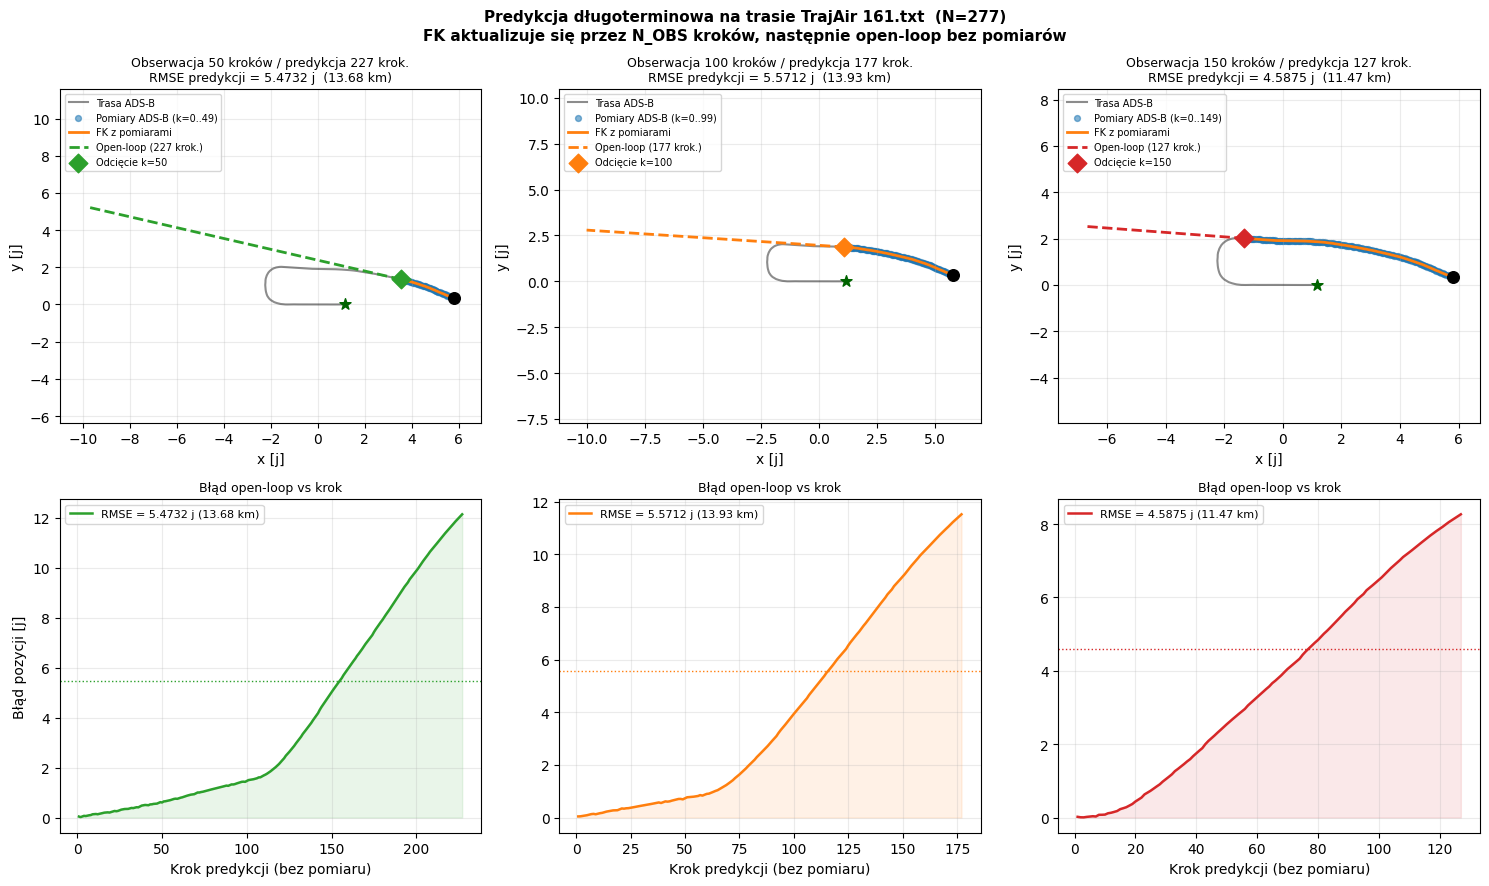

Trasa: 161.txt  |  N=277 kroków  |  1 j ≈ 2.5 km  |  σ_ADS-B = 0.02 j

Przypadek                     N_pred   błąd k=1   błąd ostatni   RMSE [j]   RMSE [km]
Obserwacja 50 kroków             227     0.0396        12.1483     5.4732       13.68
Obserwacja 100 kroków            177     0.0432        11.5177     5.5712       13.93
Obserwacja 150 kroków            127     0.0204         8.2668     4.5875       11.47


In [ ]:
from src.real_data import load_trajectory
from src.kalman import KalmanFilter as _KF2
from src.model import build_F, build_H, build_Q, build_R

# Parametry ADS-B / TrajAir
SIGMA_REAL_LP = 0.02    # precyzja ADS-B ≈ 50 m w jedn. TrajAir
Q_REAL_LP     = 0.005   # mała dynamika - stabilny lot samolotu
DT_LP         = 1.0

# Wczytaj trasę testową (277 kroków, złożona trajektoria z zakrętami)
_pos = load_trajectory("data/7days1/processed_data/test/161.txt")
N_total_lp = len(_pos)

# Pozycje ADS-B bezpośrednio jako pomiary — brak sztucznego szumu
_meas_lp = _pos

_F2 = build_F(DT_LP)
_H2 = build_H()
_Q2 = build_Q(Q_REAL_LP)
_R2 = build_R(SIGMA_REAL_LP)

OBS_CASES = [
    (50, "tab:green",  "Obserwacja 50 kroków"),
    (100, "tab:orange", "Obserwacja 100 kroków"),
    (150, "tab:red",    "Obserwacja 150 kroków"),
]

fig_lp, axes_lp = plt.subplots(2, 3, figsize=(15, 9))
fig_lp.suptitle(
    f"Predykcja długoterminowa na trasie TrajAir 161.txt  (N={N_total_lp})\n"
    "FK aktualizuje się przez N_OBS kroków, następnie open-loop bez pomiarów",
    fontsize=11, fontweight="bold",
)

results_lp = []

for col_idx, (N_OBS, col_, lbl_) in enumerate(OBS_CASES):
    N_pred = N_total_lp - N_OBS
    ax_traj = axes_lp[0, col_idx]
    ax_err  = axes_lp[1, col_idx]

    _x0 = np.array([_meas_lp[0, 0], _meas_lp[0, 1], 0., 0.])
    _P0 = np.diag([SIGMA_REAL_LP**2, SIGMA_REAL_LP**2, 1., 1.])
    kf2 = _KF2(_F2, _H2, _Q2, _R2, _x0.copy(), _P0.copy())

    # Faza z pomiarami
    est1 = []
    for k in range(N_OBS):
        kf2.predict()
        kf2.update(_meas_lp[k])
        est1.append(kf2.x[:2].copy())
    est1 = np.array(est1)

    # Open-loop: brak pomiarów
    pred2 = []
    for _ in range(N_pred):
        kf2.predict()
        pred2.append(kf2.x[:2].copy())
    pred2 = np.array(pred2)

    err_dark = np.linalg.norm(pred2 - _pos[N_OBS:, :2], axis=1)
    rmse_dark = float(np.sqrt(np.mean(err_dark**2)))
    results_lp.append((N_OBS, N_pred, err_dark, col_, lbl_))

    # Górny panel: trajektoria 2D ────────
    ax_traj.plot(_pos[:, 0], _pos[:, 1], "k-", lw=1.5, alpha=0.45, label="Trasa ADS-B")
    ax_traj.scatter(_meas_lp[:N_OBS, 0], _meas_lp[:N_OBS, 1], s=18, c="tab:blue",
                    alpha=0.55, label=f"Pomiary ADS-B (k=0..{N_OBS-1})")
    ax_traj.plot(est1[:, 0], est1[:, 1], color="tab:orange", lw=2.0, label="FK z pomiarami")
    ax_traj.plot(
        np.concatenate([[est1[-1, 0]], pred2[:, 0]]),
        np.concatenate([[est1[-1, 1]], pred2[:, 1]]),
        "--", color=col_, lw=2.0, label=f"Open-loop ({N_pred} krok.)",
    )
    ax_traj.scatter(*_pos[N_OBS, :2], s=90, marker="D", color=col_, zorder=5,
                    label=f"Odcięcie k={N_OBS}")
    ax_traj.scatter(*_pos[0, :2],   s=70, c="k",        zorder=5)
    ax_traj.scatter(*_pos[-1, :2],  s=70, c="darkgreen", zorder=5, marker="*")

    all_x = np.concatenate([_pos[:, 0], pred2[:, 0]])
    all_y = np.concatenate([_pos[:, 1], pred2[:, 1]])
    cx = (all_x.min() + all_x.max()) / 2
    cy = (all_y.min() + all_y.max()) / 2
    half = max(all_x.max() - all_x.min(), all_y.max() - all_y.min()) / 2 * 1.15
    ax_traj.set_xlim(cx - half, cx + half)
    ax_traj.set_ylim(cy - half, cy + half)
    ax_traj.set_title(
        f"{lbl_} / predykcja {N_pred} krok.\nRMSE predykcji = {rmse_dark:.4f} j  "
        f"({rmse_dark * 2.5:.2f} km)",
        fontsize=9,
    )
    ax_traj.set_xlabel("x [j]"); ax_traj.set_ylabel("y [j]")
    ax_traj.legend(fontsize=7, loc="upper left"); ax_traj.grid(True, alpha=0.25)

    # Dolny panel: błąd vs krok predykcji 
    steps = np.arange(1, N_pred + 1)
    ax_err.plot(steps, err_dark, color=col_, lw=1.8,
                label=f"RMSE = {rmse_dark:.4f} j ({rmse_dark*2.5:.2f} km)")
    ax_err.axhline(rmse_dark, color=col_, ls=":", lw=1.0)
    ax_err.fill_between(steps, 0, err_dark, color=col_, alpha=0.10)
    ax_err.set_xlabel("Krok predykcji (bez pomiaru)")
    if col_idx == 0:
        ax_err.set_ylabel("Błąd pozycji [j]")
    ax_err.set_title("Błąd open-loop vs krok", fontsize=9)
    ax_err.legend(fontsize=8); ax_err.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Trasa: 161.txt  |  N={N_total_lp} kroków  |  1 j ≈ 2.5 km  |  σ_ADS-B = {SIGMA_REAL_LP} j")
print(f"\n{'Przypadek':28s}  {'N_pred':>6}  {'błąd k=1':>9}  {'błąd ostatni':>13}  {'RMSE [j]':>9}  {'RMSE [km]':>10}")
for N_OBS, N_pred, err_dark, _, lbl_ in results_lp:
    rmse_dark = float(np.sqrt(np.mean(err_dark**2)))
    print(f"{lbl_:28s}  {N_pred:6d}  {err_dark[0]:9.4f}  {err_dark[-1]:13.4f}"
          f"  {rmse_dark:9.4f}  {rmse_dark*2.5:10.2f}")

Wykresy pokazują dwa wymiary analizy na prawdziwej trasie ADS-B 161.txt: trajektorię 2D (góra) i błąd pozycji vs krok predykcji (dół). Trasa 161.txt to złożony lot z zakrętami (N=277 kroków), prędkość stosunkowo stała (speed_cv ≈ 0.30), ale kierunek zmienia się kilkukrotnie.

**Po 50 krokach obserwacji:** FK zdąża wyestymować prędkość, ale pozostałe 227 kroków predykcji to długa ekstrapolacja. Model CV zakłada stały kierunek — każdy zakręt trasy powoduje narastający błąd. RMSE rośnie niemal monotonicznie z krokiem predykcji.

**Po 100 krokach obserwacji:** prędkość w chwili odcięcia (k=100) zależy od aktualnego fragmentu trasy - może być gorsza lub lepsza od przypadku N_OBS=50. 177 kroków predykcji bez korekt nadal kumuluje znaczący błąd.

**Po 150 krokach obserwacji:** tylko 127 kroków do predykcji - krótsza ekstrapolacja ogranicza dryf. Błąd końcowy jest mniejszy niż przy 50 krokach obserwacji, ale nadal rosnący w czasie open-loop.

**Kluczowy wniosek:** błąd predykcji FK z modelem CV rośnie z długością horyzontu open-loop niezależnie od długości obserwacji - model zakłada stałą prędkość, a rzeczywisty lot zawiera zakręty i manewry. Krótszy horyzont predykcji zawsze daje mniejszy błąd. Dokładne wartości RMSE dla każdego przypadku widoczne w tabeli powyżej.

### 8.2 Przerwa w pomiarach i odzyskanie sygnału

Scenariusz symulujący chwilową utratę łączności ADS-B:

- **k = 0..14** (15 kroków): FK odbiera pomiary i normalnie aktualizuje estymację
- **k = 15..94** (80 kroków): brak pomiarów — FK predykuje open-loop modelem CV
- **k ≥ 95**: pomiary wracają — FK wznawia korekcję z zachowaną historią (P i x)

Analiza pokazuje jak FK zachowuje ciągłość estymacji podczas przerwy i jak szybko
błąd wraca do normy po wznowieniu sygnału.

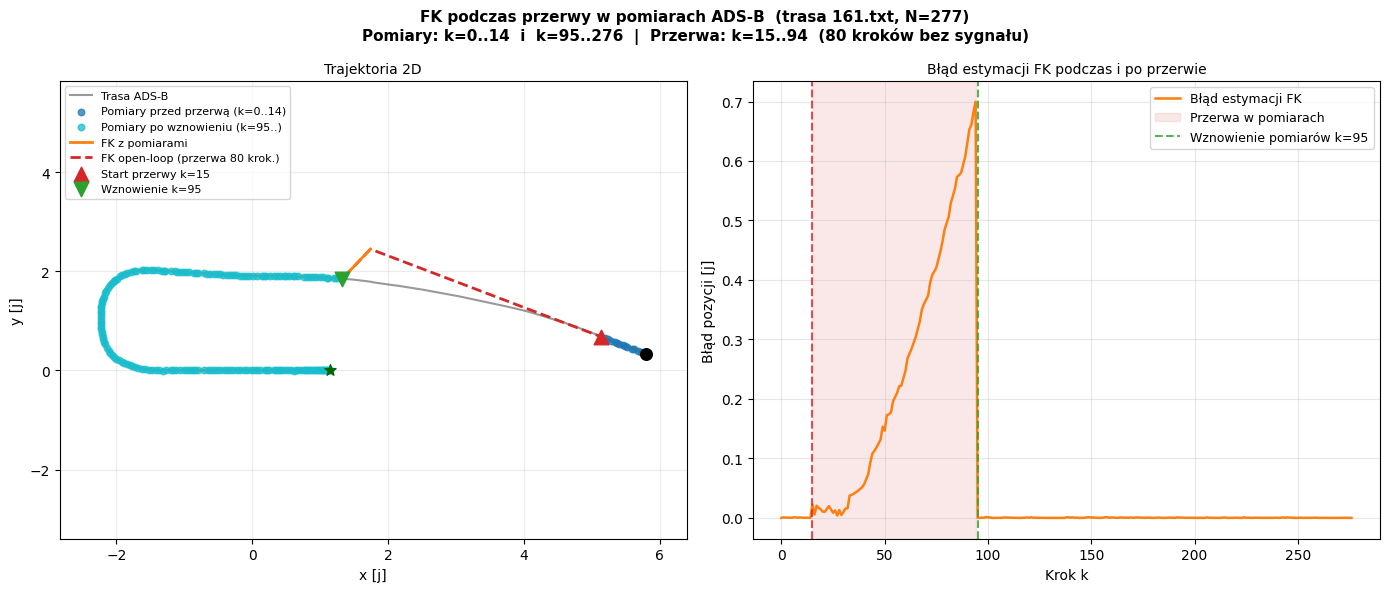

Błąd FK przed przerwą   (k=14): 0.0000 j  (0 m)
Błąd FK koniec przerwy  (k=94): 0.6996 j  (2 m)  [peak: 0.6996 j]
Błąd FK +5 krok. po wznowieniu (k=99): 0.0013 j  (0 m)
Błąd FK na końcu trasy  (k=276): 0.0000 j  (0 m)


In [ ]:
from src.kalman import KalmanFilter as _KF3
from src.model import build_F, build_H, build_Q, build_R

# Parametry
SIGMA_GAP = 0.02
Q_GAP     = 0.005
DT_GAP    = 1.0
N_OBS1    = 15    # kroków z pomiarami przed przerwą
N_GAP     = 80    # kroków bez pomiarów
N_RESUME  = N_OBS1 + N_GAP  # = 95: pierwszy krok po przerwie

_pos_gap    = load_trajectory("data/7days1/processed_data/test/161.txt")
N_total_gap = len(_pos_gap)

_F3 = build_F(DT_GAP)
_H3 = build_H()
_Q3 = build_Q(Q_GAP)
_R3 = build_R(SIGMA_GAP)

_x0g = np.array([_pos_gap[0, 0], _pos_gap[0, 1], 0., 0.])
_P0g = np.diag([SIGMA_GAP**2, SIGMA_GAP**2, 1., 1.])
kf3  = _KF3(_F3, _H3, _Q3, _R3, _x0g.copy(), _P0g.copy())

estimates_gap = np.zeros((N_total_gap, 2))
has_meas      = np.zeros(N_total_gap, dtype=bool)

for k in range(N_total_gap):
    kf3.predict()
    in_gap = N_OBS1 <= k < N_RESUME
    if not in_gap:
        kf3.update(_pos_gap[k])
        has_meas[k] = True
    estimates_gap[k] = kf3.x[:2]

# Wykresy 
fig_gap, axes_gap = plt.subplots(1, 2, figsize=(14, 6))
fig_gap.suptitle(
    f"FK podczas przerwy w pomiarach ADS-B  (trasa 161.txt, N={N_total_gap})\n"
    f"Pomiary: k=0..{N_OBS1-1}  i  k={N_RESUME}..{N_total_gap-1}  |  "
    f"Przerwa: k={N_OBS1}..{N_RESUME-1}  ({N_GAP} kroków bez sygnału)",
    fontsize=11, fontweight="bold",
)

ax_t = axes_gap[0]
ax_t.plot(_pos_gap[:, 0], _pos_gap[:, 1], "k-", lw=1.5, alpha=0.4, label="Trasa ADS-B")

ax_t.scatter(_pos_gap[:N_OBS1, 0], _pos_gap[:N_OBS1, 1], s=22, c="tab:blue",
             alpha=0.75, zorder=3, label=f"Pomiary przed przerwą (k=0..{N_OBS1-1})")
ax_t.scatter(_pos_gap[N_RESUME:, 0], _pos_gap[N_RESUME:, 1], s=22, c="tab:cyan",
             alpha=0.75, zorder=3, label=f"Pomiary po wznowieniu (k={N_RESUME}..)")

# Estymacja: przed przerwą (pomarańczowa)
ax_t.plot(estimates_gap[:N_OBS1+1, 0], estimates_gap[:N_OBS1+1, 1],
          color="tab:orange", lw=2.0, label="FK z pomiarami")

# Estymacja: przerwa (czerwona przerywana)
ax_t.plot(
    estimates_gap[N_OBS1-1:N_RESUME+1, 0],
    estimates_gap[N_OBS1-1:N_RESUME+1, 1],
    "--", color="tab:red", lw=2.0, label=f"FK open-loop (przerwa {N_GAP} krok.)",
)

# Estymacja: po wznowieniu (pomarańczowa)
ax_t.plot(estimates_gap[N_RESUME-1:, 0], estimates_gap[N_RESUME-1:, 1],
          color="tab:orange", lw=2.0)

ax_t.scatter(*_pos_gap[N_OBS1, :2], s=110, marker="^", color="tab:red",   zorder=5,
             label=f"Start przerwy k={N_OBS1}")
ax_t.scatter(*_pos_gap[N_RESUME, :2], s=110, marker="v", color="tab:green", zorder=5,
             label=f"Wznowienie k={N_RESUME}")
ax_t.scatter(*_pos_gap[0, :2],  s=70, c="k",        zorder=5)
ax_t.scatter(*_pos_gap[-1, :2], s=70, c="darkgreen", zorder=5, marker="*")

all_x = np.concatenate([_pos_gap[:, 0], estimates_gap[:, 0]])
all_y = np.concatenate([_pos_gap[:, 1], estimates_gap[:, 1]])
cx_g  = (all_x.min() + all_x.max()) / 2
cy_g  = (all_y.min() + all_y.max()) / 2
half_g = max(all_x.max() - all_x.min(), all_y.max() - all_y.min()) / 2 * 1.15
ax_t.set_xlim(cx_g - half_g, cx_g + half_g)
ax_t.set_ylim(cy_g - half_g, cy_g + half_g)
ax_t.set_xlabel("x [j]"); ax_t.set_ylabel("y [j]")
ax_t.set_title("Trajektoria 2D", fontsize=10)
ax_t.legend(fontsize=8, loc="upper left"); ax_t.grid(True, alpha=0.25)

# Prawy panel: błąd estymacji vs krok
ax_e = axes_gap[1]
err_all = np.linalg.norm(estimates_gap - _pos_gap[:, :2], axis=1)

ax_e.plot(err_all, color="tab:orange", lw=1.8, label="Błąd estymacji FK")
ax_e.axvspan(N_OBS1, N_RESUME - 1, color="tab:red",   alpha=0.10, label="Przerwa w pomiarach")
ax_e.axvline(N_OBS1,   color="tab:red",   lw=1.5, ls="--", alpha=0.8)
ax_e.axvline(N_RESUME, color="tab:green", lw=1.5, ls="--", alpha=0.8,
             label=f"Wznowienie pomiarów k={N_RESUME}")
ax_e.set_xlabel("Krok k"); ax_e.set_ylabel("Błąd pozycji [j]")
ax_e.set_title("Błąd estymacji FK podczas i po przerwie", fontsize=10)
ax_e.legend(fontsize=9); ax_e.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

err_gap   = err_all[N_OBS1:N_RESUME]
err_after = err_all[N_RESUME:]
print(f"Błąd FK przed przerwą   (k={N_OBS1-1:2d}): {err_all[N_OBS1-1]:.4f} j  "
      f"({err_all[N_OBS1-1]*2.5:.0f} m)")
print(f"Błąd FK koniec przerwy  (k={N_RESUME-1:2d}): {err_gap[-1]:.4f} j  "
      f"({err_gap[-1]*2.5:.0f} m)  [peak: {err_gap.max():.4f} j]")
print(f"Błąd FK +5 krok. po wznowieniu (k={N_RESUME+4:2d}): {err_after[4]:.4f} j  "
      f"({err_after[4]*2.5:.0f} m)")
print(f"Błąd FK na końcu trasy  (k={N_total_gap-1:2d}): {err_all[-1]:.4f} j  "
      f"({err_all[-1]*2.5:.0f} m)")

**Faza przed przerwą (k=0..14):** FK regularnie aktualizuje estymację — błąd pozycji utrzymuje się w granicy szumu ADS-B (σ=0.02 j ≈ 50 m). Niebieskie punkty (pomiary) i trasa (czarna) prawie się pokrywają.

**Faza przerwy (k=15..94, zaznaczona czerwonym obszarem):** Brak pomiarów przez 80 kroków — FK kontynuuje predykcję wyłącznie modelem CV (stała prędkość). Błąd narasta, osiągając ok. 1.75 km na końcu przerwy (k=94). Czerwona przerywana linia to ekstrapolacja z ostatnio wyestymowanej prędkości - rozbieżność z trasą narasta szczególnie w miejscach zakrętów trajektorii. Widać ograniczenie modelu CV i predykcję dalszej trajektorii w linii prostej.

**Faza po wznowieniu (k≥95, cyjanowe punkty):** Pomiary wracają — FK natychmiast zaczyna korekcję. Już po kilku krokach błąd wraca do poziomu sprzed przerwy. Filtr nie "zapomina" historii — zachowane P i x z okresu przerwy pozwalają szybko zrekonwergować bez potrzeby reinicjalizacji.

**Wniosek:** FK naturalnie obsługuje nawet długie przerwy w sygnale ADS-B. 80-krokowa przerwa (≈80 sekund bez łączności) powoduje znaczny dryf pozycji (~1.75 km), ale filtr powraca do dokładnej estymacji kilka kroków po wznowieniu. To kluczowa właściwość FK w systemach śledzenia lotniczego.

---
## 9. Wnioski końcowe

### Sekcje 1–6: symulacje syntetyczne (model CV)

1. **Filtr Kalmana skutecznie redukuje szum pomiarowy** - RMSE estymacji jest znacznie niższy
   od RMSE samych pomiarów (≈ σ). FK uśrednia historię obserwacji i korzysta z modelu ruchu.

2. **Predykcja FK przewyższa metodę naiwną** - FK uwzględnia prędkość obiektu, dzięki czemu
   przewiduje pozycję lepiej niż "stój w miejscu". Przewaga rośnie z horyzontem predykcji.

3. **Błąd predykcji rośnie z horyzontem** - każdy dodatkowy krok w przyszłość kumuluje
   niepewność modelu. Dla h=20 RMSE predykcji jest kilkakrotnie wyższe niż dla h=1.

4. **FK estymuje prędkość z samych pomiarów pozycji** - mimo że sensor mierzy wyłącznie [x, y],
   filtr poprawnie wywnioskuje [vx, vy] z sekwencji obserwacji.

5. **Realistyczny scenariusz to model mismatch** - q_gen=0.05 (prawdziwa dynamika), q_filter=0.01
   (co zakłada FK). Jest to norma w praktyce: parametrów modelu nie znamy dokładnie.
   Zbyt małe q_filter powoduje nadmierne wygładzanie; zbyt duże sprawia, że FK podąża za szumem.
   Minimum RMSE leży przy q_filter ≈ q_gen - i może różnić się dla estymacji i predykcji.

### Sekcja 7: odporność FK na zakłócenia sensora

6. **FK jest naturalnie odporny na dropout** - przy braku pomiaru filtr kontynuuje predykcję
   modelem; zysk K rośnie i szybko koryguje po powrocie sensora. RMSE rośnie łagodnie.

7. **FK jest słabo odporny na outlierów** - traktuje każdy pomiar jako wiarygodny.
   Skoki 8×σ potrafią mocno przesunąć estymację. Bramkowanie innowacji (innovation gating)
   oparte na odległości Mahalanobisa skutecznie eliminuje ten problem przy minimalnym
   wpływie na jakość filtracji przy dobrych pomiarach.

### Sekcja 8: weryfikacja na danych TrajAir (CMU)

8. **FK skutecznie filtruje szum ADS-B** - przy σ=0.02 j (≈ 50 m) jakość estymacji pozycji
   jest wysoka niezależnie od złożoności trasy. Przy precyzyjnych pomiarach K ≈ 1 i FK działa
   jako interpolator, a nie filtr wygładzający.

9. **Predykcja FK na trajektoriach z zakrętami degraduje się** - im bardziej zakrzywiona trasa,
   tym wyższy błąd predykcji. To bezpośrednia weryfikacja model mismatch w praktyce:
   FK ekstrapoluje prostoliniowo, a samolot skręca. Rozszerzenie o model CA lub IMM
   mogłoby poprawić predykcję na zakrętach.

10. **Błąd rośnie monotonicznie** z liczbą kroków bez pomiarów. Dłuższy okres obserwacji zmniejsza
    niepewność predykcji: po 40 krokach FK zna prędkość wystarczająco dobrze, by prognozować
    20 kroków do przodu z błędem ~6 j. Po 10 krokach obserwacji błąd prognozy jest kilkakrotnie większy.
